In [1]:
import os
import numpy as np
import pandas as pd

from sklearn.metrics import (r2_score)
from sklearn.manifold import TSNE

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
import seaborn as sns

In [2]:
os.getcwd()

'/Users/nadav/Dropbox/lastChance/whyScoresAreDifferent/githubRepository/contentVsForm/src'

In [3]:
FIG_SIZE = (12,6)
SAVE_DIR = "../../output/"

K_LABELS = {
    0: "Original text",
    1: "SAT 1",
    2: "SAT 2",
    3: "SAT 3",
    4: "SAT 4",
    5: "SAT 5",
    6: "SAT 6"
}

In [4]:
# The original full dataset processed + its embeddings
df_persuade = pd.read_csv("../../data/persuade/persuade_full_cleaned.csv")
full_embeddings = np.load("../../data/embeddings/embeddings_full.npy")

# the low and high scorer output datasets + their embeddings
# df_low_scorer = pd.read_csv("../../model/run_01/data_low_scored.csv") XX?
# df_high_scorer = pd.read_csv("../../model/run_01/data_high_scored.csv") XX?

low_embeddings = np.load("../../data/embeddings/embeddings_low_v2.npy") #XX? changed to vs 
high_embeddings = np.load("../../data/embeddings/embeddings_high_v2.npy") #XX? changed to vs 

# The results of the scorer run
results_df = pd.read_csv("../../data/results/sat_full/data_sat_scored.csv")

# The decomposition results
df_decomp = pd.read_csv("../../data/results/sat_full/decomp_rows_with_fe.csv", index_col=0)

-----

# Original Dataset Vizualizations

### Distribution of SES scores (Low x High)

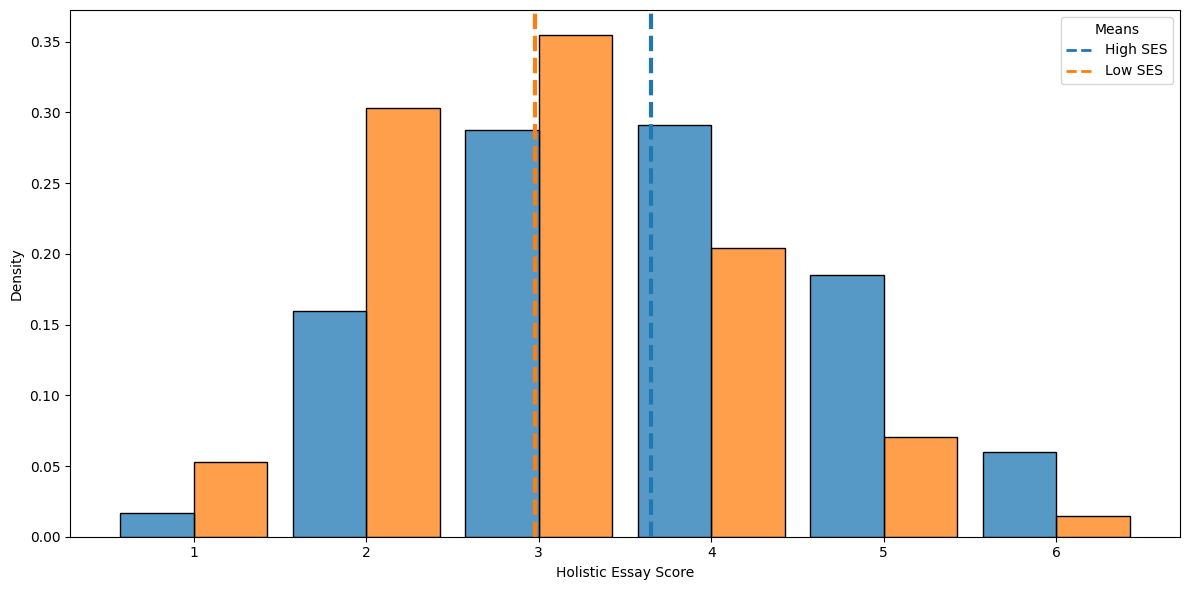

In [5]:
plt.figure(figsize=FIG_SIZE)

sns.histplot(
    data=df_persuade,
    x="holistic_essay_score",
    hue="economically_disadvantaged",
    bins=np.arange(0.5, 6.5 + 1, 1),
    stat="density",
    multiple="dodge",
    shrink=0.85,
    common_norm=False,
    palette={0: "tab:blue", 1: "tab:orange"},
    legend=False
)

mean_high = df_persuade.loc[df_persuade["economically_disadvantaged"] == 0, "holistic_essay_score"].mean()
mean_low  = df_persuade.loc[df_persuade["economically_disadvantaged"] == 1, "holistic_essay_score"].mean()

plt.axvline(mean_high, color="tab:blue", linestyle="--", linewidth=3)
plt.axvline(mean_low,  color="tab:orange", linestyle="--", linewidth=3)

plt.legend(
    handles=[
        Line2D([0], [0], color="tab:blue", linestyle="--", lw=2, label="High SES"),
        Line2D([0], [0], color="tab:orange", linestyle="--", lw=2, label="Low SES")
    ],
    title="Means"
)


plt.xlabel("Holistic Essay Score")
plt.ylabel("Density")
plt.savefig(SAVE_DIR + "real_scores.pdf")
plt.tight_layout()
plt.show()


### Mean score distribuition - by prompts (questions)

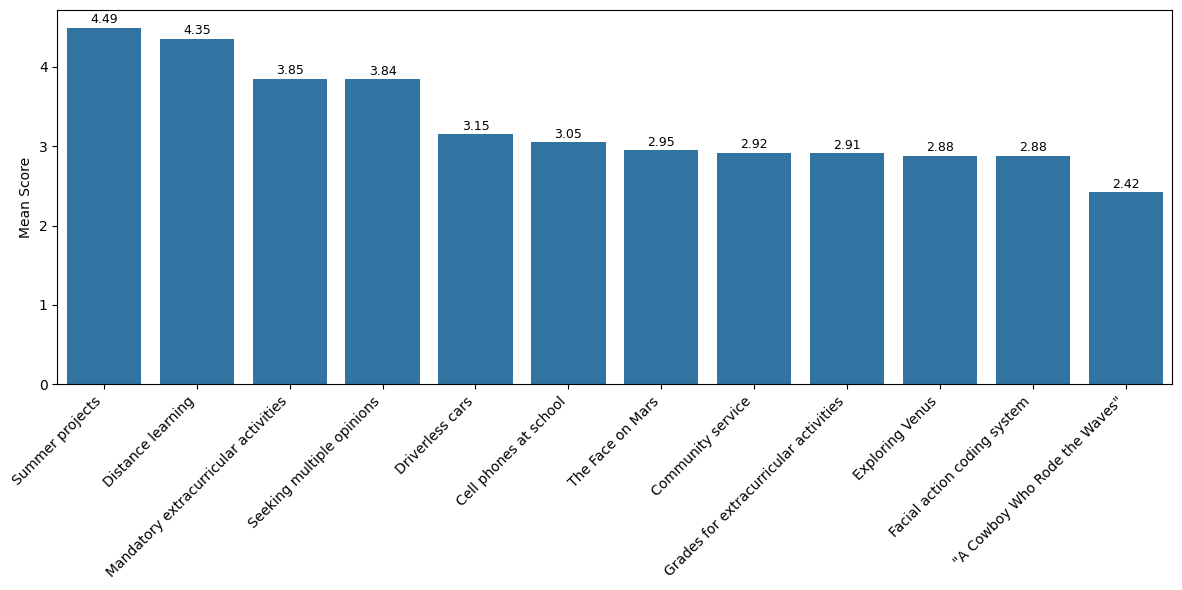

In [6]:
# --- Mean table ---
mean_table = (
    df_persuade.groupby("prompt_name")["holistic_essay_score"]
    .mean()
    .round(2)
    .reset_index()
    .sort_values("holistic_essay_score", ascending=False)
)

# --- Plot ---
plt.figure(figsize=FIG_SIZE)
sns.barplot(
    data=mean_table,
    x="prompt_name",
    y="holistic_essay_score",
)

# Add value labels on top of bars
for i, row in enumerate(mean_table.itertuples()):
    plt.text(
        i, row.holistic_essay_score + 0.02,  # small offset
        f"{row.holistic_essay_score:.2f}",
        ha="center", va="bottom", fontsize=9
    )

plt.xlabel("")
plt.ylabel("Mean Score")
plt.xticks(rotation=45, ha="right")
plt.savefig(SAVE_DIR + "mean_score_prompts.pdf")
plt.tight_layout()
plt.show()

### Scatterplot Matrix for predicted scores (only on original essays)

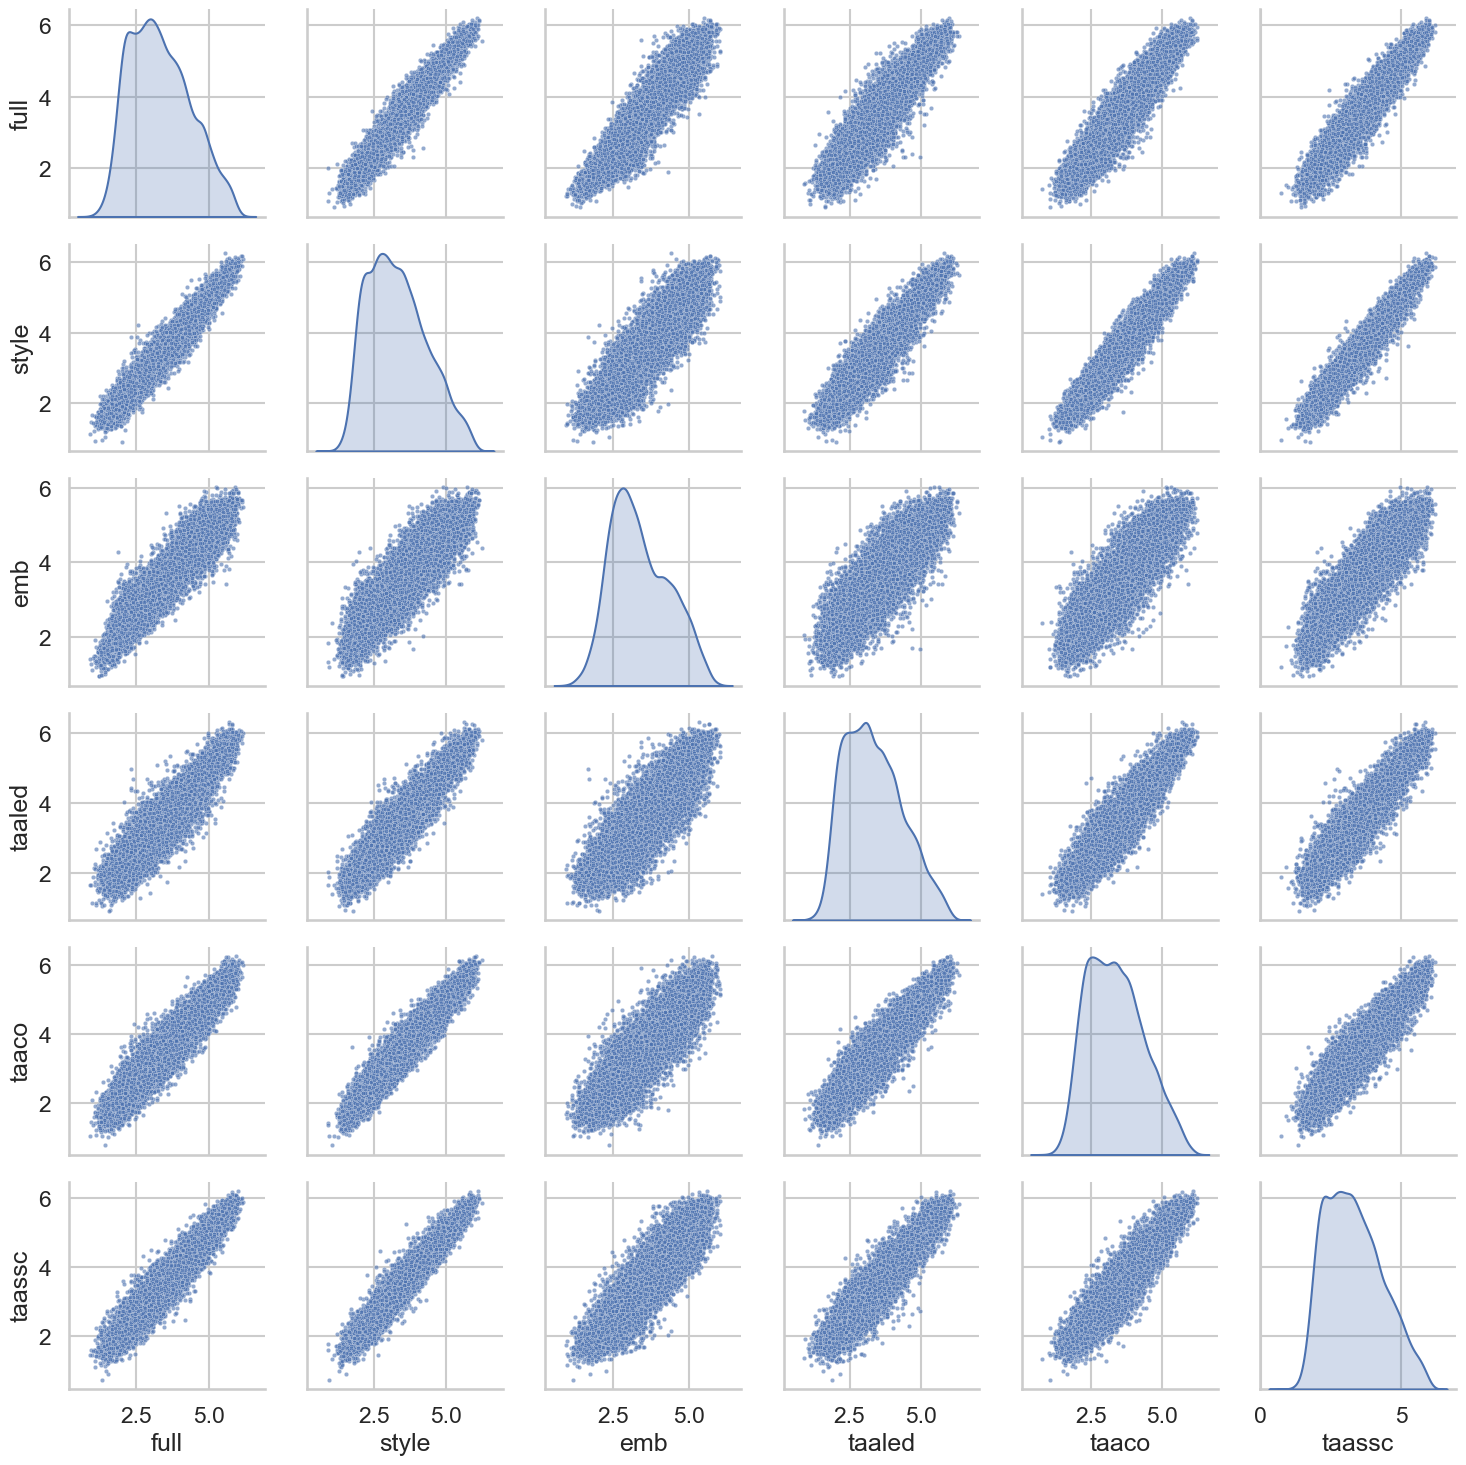

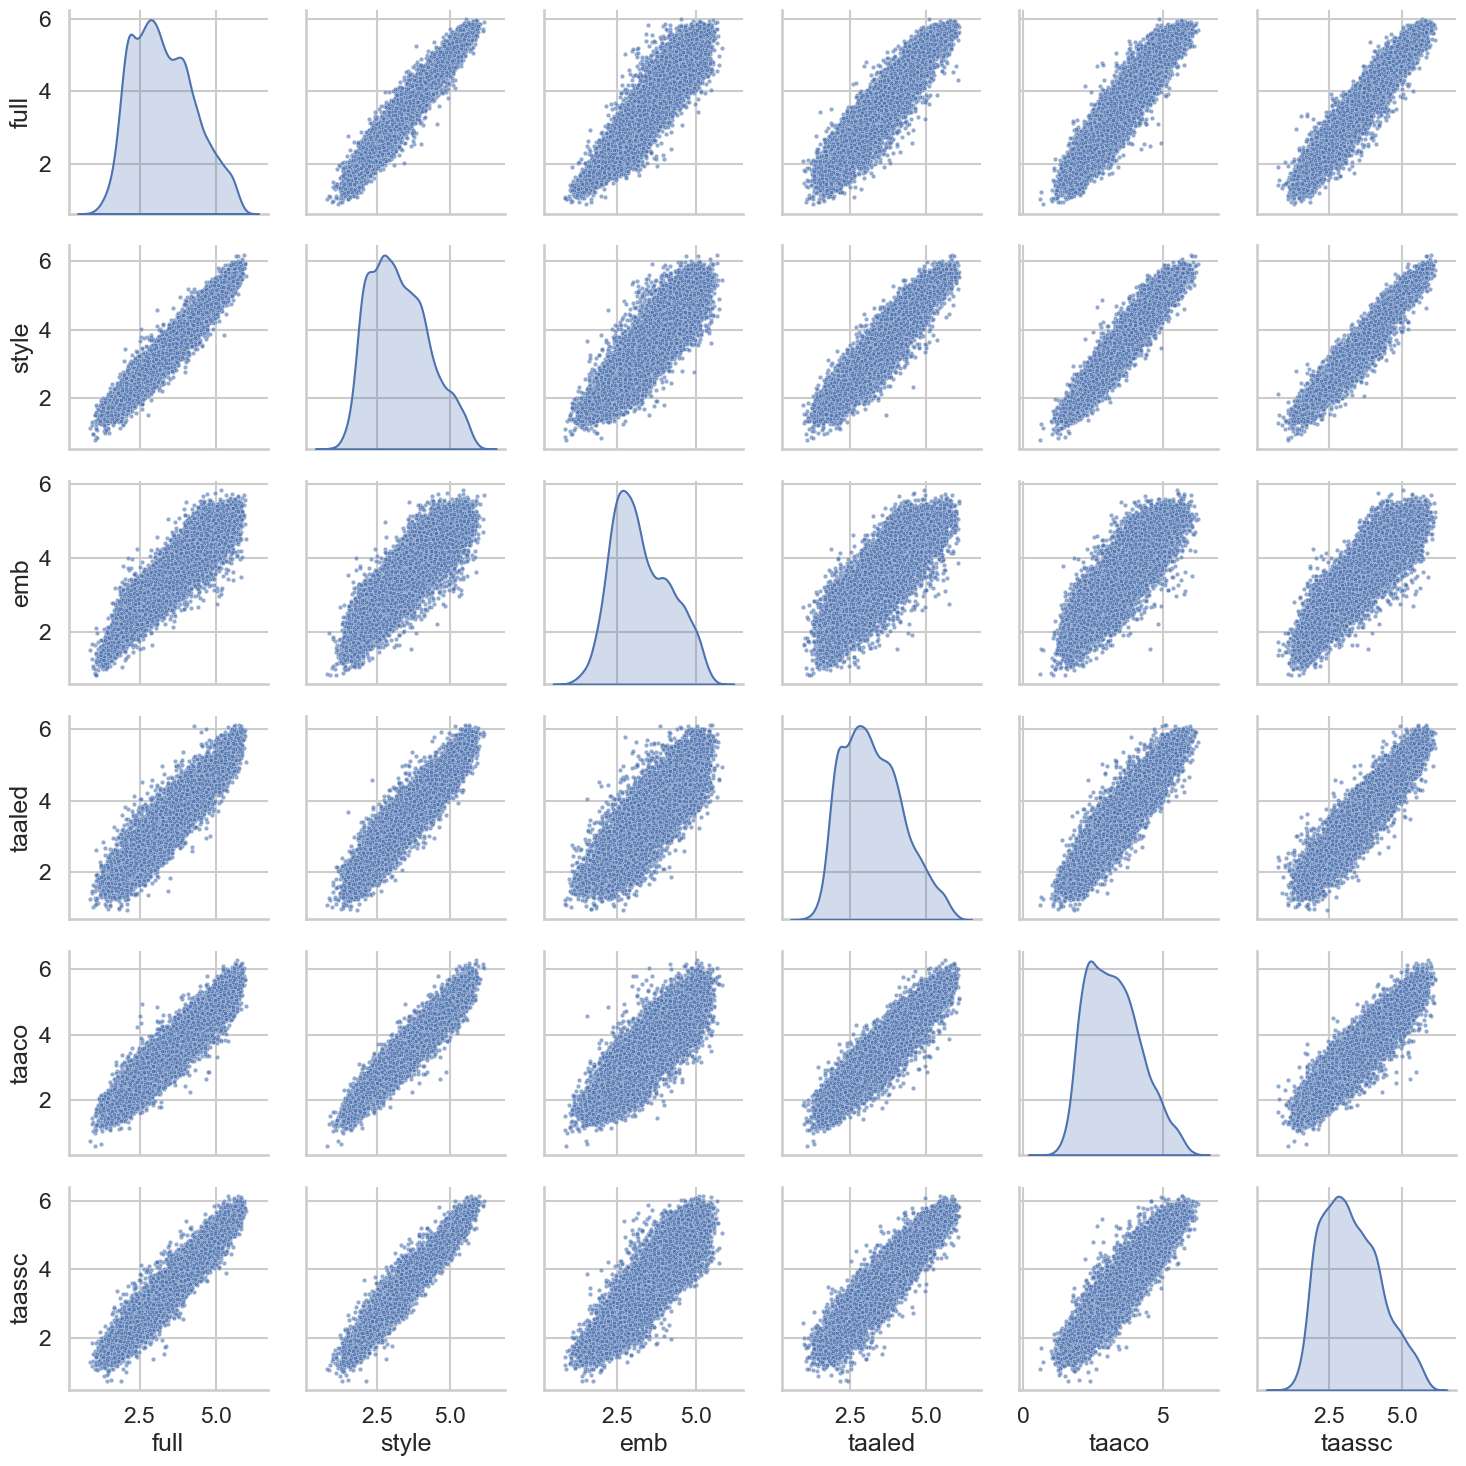

In [7]:
filtered = results_df[results_df["k"] == 0]

high_cols = [c for c in filtered.columns if c.startswith("score_high")]
low_cols  = [c for c in filtered.columns if c.startswith("score_low")]

def rename_cols(cols):
    return {c: c.split("_")[-1] for c in cols}

sns.set(style="whitegrid", context="talk")

# ---- High SES ----
high_df = filtered[high_cols].rename(columns=rename_cols(high_cols))
g1 = sns.pairplot(high_df, diag_kind="kde", plot_kws=dict(s=10, alpha=0.6))
plt.savefig(f"{SAVE_DIR}scatter_matrix_high_ses.pdf", bbox_inches="tight")
plt.tight_layout()
plt.show()

# ---- Low SES ----
low_df = filtered[low_cols].rename(columns=rename_cols(low_cols))
g2 = sns.pairplot(low_df, diag_kind="kde", plot_kws=dict(s=10, alpha=0.6))
plt.savefig(f"{SAVE_DIR}scatter_matrix_low_ses.pdf", bbox_inches="tight")
plt.tight_layout()
plt.show()

### Binned Values - predicted x estimated mean (Low SES)

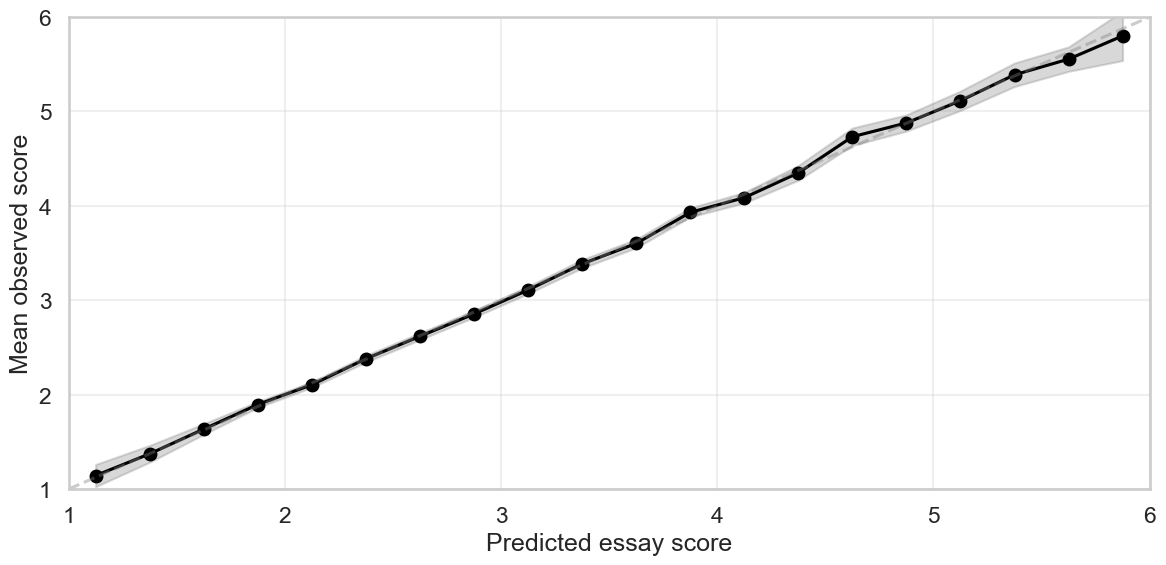

In [8]:
df_low = filtered.query("low_SES == 1").copy()

bins = np.linspace(1, 6, 21)
binned = pd.cut(df_low["score_low_full"], bins=bins, include_lowest=True, right=True)

stats = df_low.groupby(binned, observed=True)["true_score"].agg(["mean", "count", "std"])
stats["se"] = stats["std"] / np.sqrt(stats["count"])
stats.loc[stats["count"] <= 1, "se"] = np.nan
stats["ci"] = 1.96 * stats["se"]

centers = stats.index.map(lambda iv: (iv.left + iv.right) / 2).astype(float)
mask = stats["count"] >= 10

plt.figure(figsize=FIG_SIZE)
plt.plot(centers[mask], stats["mean"][mask], marker="o", color="black")
plt.fill_between(
    centers[mask],
    stats["mean"][mask] - stats["ci"][mask],
    stats["mean"][mask] + stats["ci"][mask],
    alpha=0.3, color="gray"
)
plt.plot([1, 6], [1, 6], "--", alpha=0.4, color="gray")
plt.xlim(1, 6); plt.ylim(1, 6)
plt.xlabel("Predicted essay score"); plt.ylabel("Mean observed score")
plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(f"{SAVE_DIR}binned_low.pdf")
plt.show()

### Binned Values - predicted x estimated mean (High SES)

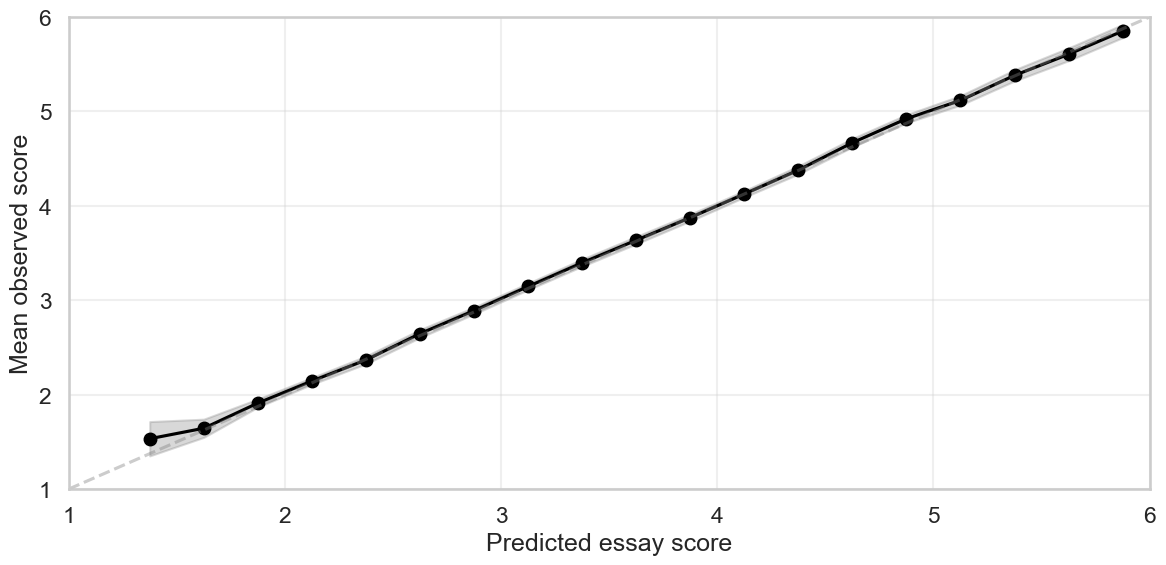

In [9]:
# Compact binned calibration plot (high SES only)
df_high = filtered.query("low_SES == 0").copy()

bins = np.linspace(1, 6, 21)
binned = pd.cut(df_high["score_high_full"], bins=bins, include_lowest=True, right=True)

stats = df_high.groupby(binned, observed=True)["true_score"].agg(["mean", "count", "std"])
stats["se"] = stats["std"] / np.sqrt(stats["count"])
stats.loc[stats["count"] <= 1, "se"] = np.nan
stats["ci"] = 1.96 * stats["se"]

centers = stats.index.map(lambda iv: (iv.left + iv.right) / 2).astype(float)
mask = stats["count"] >= 10  # keep bins with enough data

plt.figure(figsize=FIG_SIZE)
plt.plot(centers[mask], stats["mean"][mask], marker="o", color="black")
plt.fill_between(
    centers[mask],
    stats["mean"][mask] - stats["ci"][mask],
    stats["mean"][mask] + stats["ci"][mask],
    alpha=0.3, color="gray"
)
plt.plot([1, 6], [1, 6], "--", alpha=0.4, color="gray")
plt.xlim(1, 6); plt.ylim(1, 6)
plt.xlabel("Predicted essay score"); plt.ylabel("Mean observed score")
plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(f"{SAVE_DIR}binned_high.pdf")
plt.show()

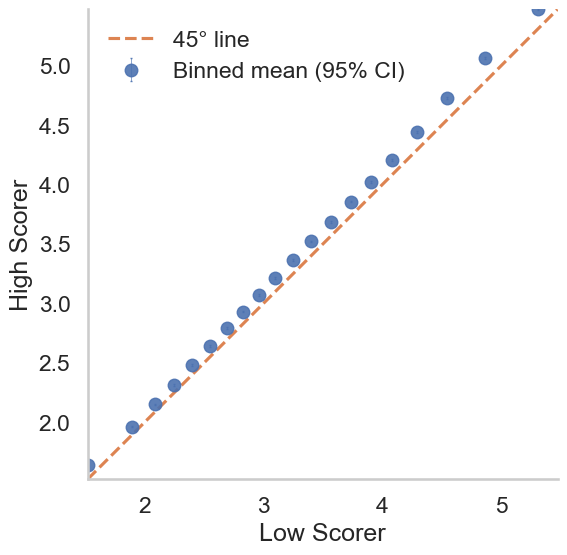

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

x = results_df['score_low_full']
y = results_df['score_high_full']

n_bins = 20
z = 1.96  # 95% CI

df = pd.DataFrame({'x': x, 'y': y}).dropna()

# Quantile (equal-count) bins
df['bin'] = pd.qcut(df['x'], q=n_bins, labels=False, duplicates='drop')

binned = (
    df.groupby('bin')
      .agg(
          x_mean=('x', 'mean'),
          y_mean=('y', 'mean'),
          y_std=('y', lambda s: s.std(ddof=1)),
          n=('y', 'size')
      )
      .reset_index()
)

binned['y_se'] = binned['y_std'] / np.sqrt(binned['n'])
binned['y_ci'] = z * binned['y_se']

plt.figure(figsize=(6, 6))

# Binned means with 95% CI
plt.errorbar(
    binned['x_mean'],
    binned['y_mean'],
    yerr=binned['y_ci'],
    fmt='o',
    capsize=1,
    elinewidth=0.5,
    alpha=0.9,
    label='Binned mean (95% CI)'
)

# 45-degree line
lims = [
    min(binned['x_mean'].min(), binned['y_mean'].min()),
    max(binned['x_mean'].max(), binned['y_mean'].max())
]
plt.plot(lims, lims, linestyle='--', label='45° line')

plt.xlim(lims)
plt.ylim(lims)

plt.xlabel("Low Scorer")
plt.ylabel("High Scorer")
plt.gca().set_aspect('equal', adjustable='box')

plt.legend(frameon=False)
plt.grid(False)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}highVsLowSESPredictor.pdf')
plt.show()

----

# Embeddings Visualizations

### 2d Embedding (High x Low) - t-SNE
* Generates the image w/ full data
* Generates the image divided by prompt names

In [11]:
X_tsne = TSNE(
    n_components=2, metric="cosine", perplexity=30,
    init="random", learning_rate="auto", random_state=42
).fit_transform(full_embeddings)

df_tsne = pd.DataFrame({
    "x": X_tsne[:, 0],
    "y": X_tsne[:, 1],
    "SES": np.where(df_persuade["economically_disadvantaged"], "Low SES", "High SES"),
    "prompt_name": df_persuade["prompt_name"].astype(str)
})

In [13]:
# --- Plot helper ---
palette_points = {"Low SES": "#7c3aed", "High SES": "#f97316"}

def plot_tsne(d, title=None, save_path=None):
    plt.figure(figsize=FIG_SIZE)
    sns.set_style("white")

    for label in ["Low SES", "High SES"]:
        dd = d[d["SES"] == label]
        if len(dd):
            plt.scatter(dd["x"], dd["y"], s=6, alpha=0.20, color=palette_points[label])

    for label, base_color in [("Low SES", "#7c3aed"), ("High SES", "#f97316")]:
        dd = d[d["SES"] == label]
        if len(dd) < 5:
            continue
        cmap = sns.light_palette(base_color, as_cmap=True)
        sns.kdeplot(data=dd, x="x", y="y", fill=True, thresh=0.02, levels=80, bw_adjust=1.0, alpha=0.75, cmap=cmap)
        sns.kdeplot(data=dd, x="x", y="y", fill=False, levels=7, bw_adjust=1.0, linewidths=1.1, cmap=cmap)

    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    handles = [
        Line2D([0], [0], color="#f97316", lw=3, label="High SES"),
        Line2D([0], [0], color="#7c3aed", lw=3, label="Low SES"),
    ]
    plt.legend(handles=handles, frameon=True)

    if title: 
        plt.title(title)

    plt.tight_layout()

    if save_path:
        plt.savefig(SAVE_DIR + f"{save_path}.pdf", dpi=300)
    
    plt.show()

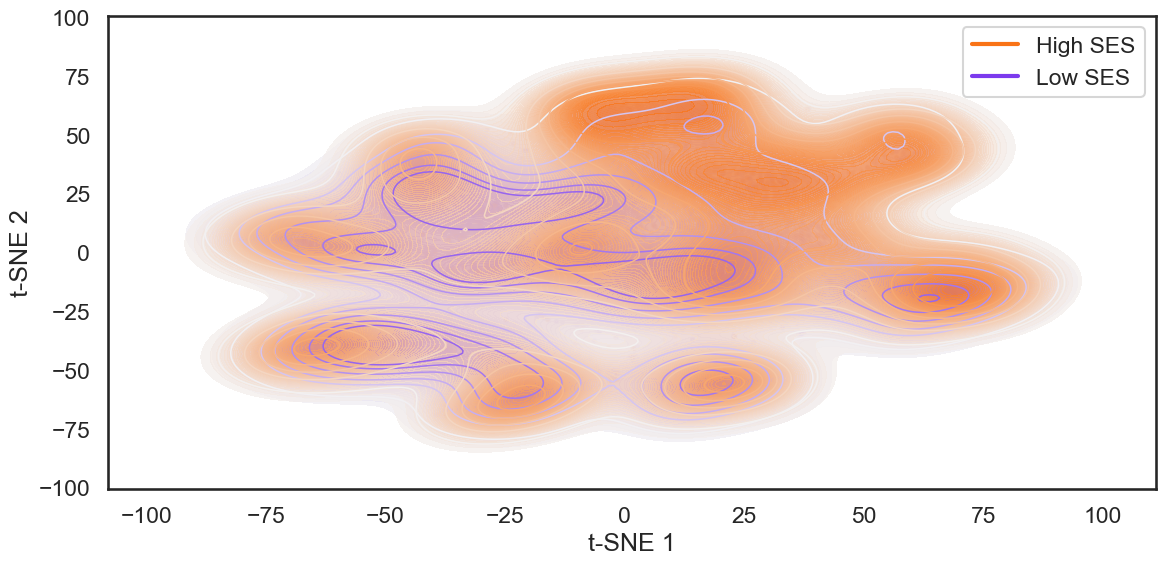

In [14]:
plot_tsne(df_tsne, save_path="t_sne_kde")

In [15]:
def plot_tsne_grid(
    df_tsne,
    rows=3,
    cols=5,
    save_path=None,

    title_fs=11,
    label_fs=10,
    tick_fs=9,
    legend_fs=11,

    point_size=8,
    point_alpha=0.25,
    kde_fill_alpha=0.70,
    kde_line_width=1.0,

    wspace=0.20,
    hspace=0.25,
    top_pad=0.90,
    bottom_pad=0.08,
    left_pad=0.06,
    right_pad=0.98,

    color_high="#f97316",
    color_low="#7c3aed",

    legend_loc="upper center",
    legend_bbox=(0.5, 1.02),   # x, y relative to figure
):

    palette_points = {
        "High SES": color_high,
        "Low SES":  color_low
    }

    # ------------------------
    # Internal function: plots a single t-SNE panel
    # ------------------------
    def plot_tsne_ax(d, ax, title=None):
        # scatter points
        for label in ["Low SES", "High SES"]:
            dd = d[d["SES"] == label]
            if len(dd):
                ax.scatter(
                    dd["x"], dd["y"],
                    s=point_size,
                    alpha=point_alpha,
                    color=palette_points[label]
                )

        # KDE layers
        for label, base_color in [("Low SES", color_low), ("High SES", color_high)]:
            dd = d[d["SES"] == label]
            if len(dd) >= 5 and dd[["x", "y"]].std().min() > 0:
                cmap = sns.light_palette(base_color, as_cmap=True)
                try:
                    sns.kdeplot(
                        data=dd, x="x", y="y",
                        fill=True, thresh=0.02,
                        bw_adjust=1.0,
                        alpha=kde_fill_alpha,
                        cmap=cmap, ax=ax
                    )
                    sns.kdeplot(
                        data=dd, x="x", y="y",
                        fill=False, levels=7,
                        bw_adjust=1.0,
                        linewidths=kde_line_width,
                        cmap=cmap, ax=ax
                    )
                except Exception:
                    pass

        ax.set_xlabel("t-SNE 1", fontsize=label_fs)
        ax.set_ylabel("t-SNE 2", fontsize=label_fs)
        ax.tick_params(labelsize=tick_fs)

        if title:
            ax.set_title(title, fontsize=title_fs)

    # ------------------------
    # Grid layout
    # ------------------------
    prompts = sorted(df_tsne["prompt_name"].unique())
    total_plots = rows * cols

    fig, axes = plt.subplots(rows, cols, figsize=(25, 15))
    axes = np.ravel(axes)

    # fill grid with prompts
    for i, p in enumerate(prompts[:total_plots]):
        d = df_tsne[df_tsne["prompt_name"] == p]
        plot_tsne_ax(d, ax=axes[i], title=p)

    # disable empty axes
    for j in range(len(prompts), total_plots):
        axes[j].axis("off")

    # shared legend
    handles = [
        Line2D([0], [0], color=color_high, lw=3, label="High SES"),
        Line2D([0], [0], color=color_low,  lw=3, label="Low SES"),
    ]

    fig.legend(
        handles=handles,
        loc=legend_loc,
        ncol=2,
        fontsize=legend_fs,
        frameon=True,
        bbox_to_anchor=legend_bbox
    )


    # adjust spacing
    fig.subplots_adjust(
        top=top_pad,
        bottom=bottom_pad,
        left=left_pad,
        right=right_pad,
        wspace=wspace,
        hspace=hspace
    )

    if save_path:
        fig.savefig(save_path, bbox_inches="tight")

    plt.show()


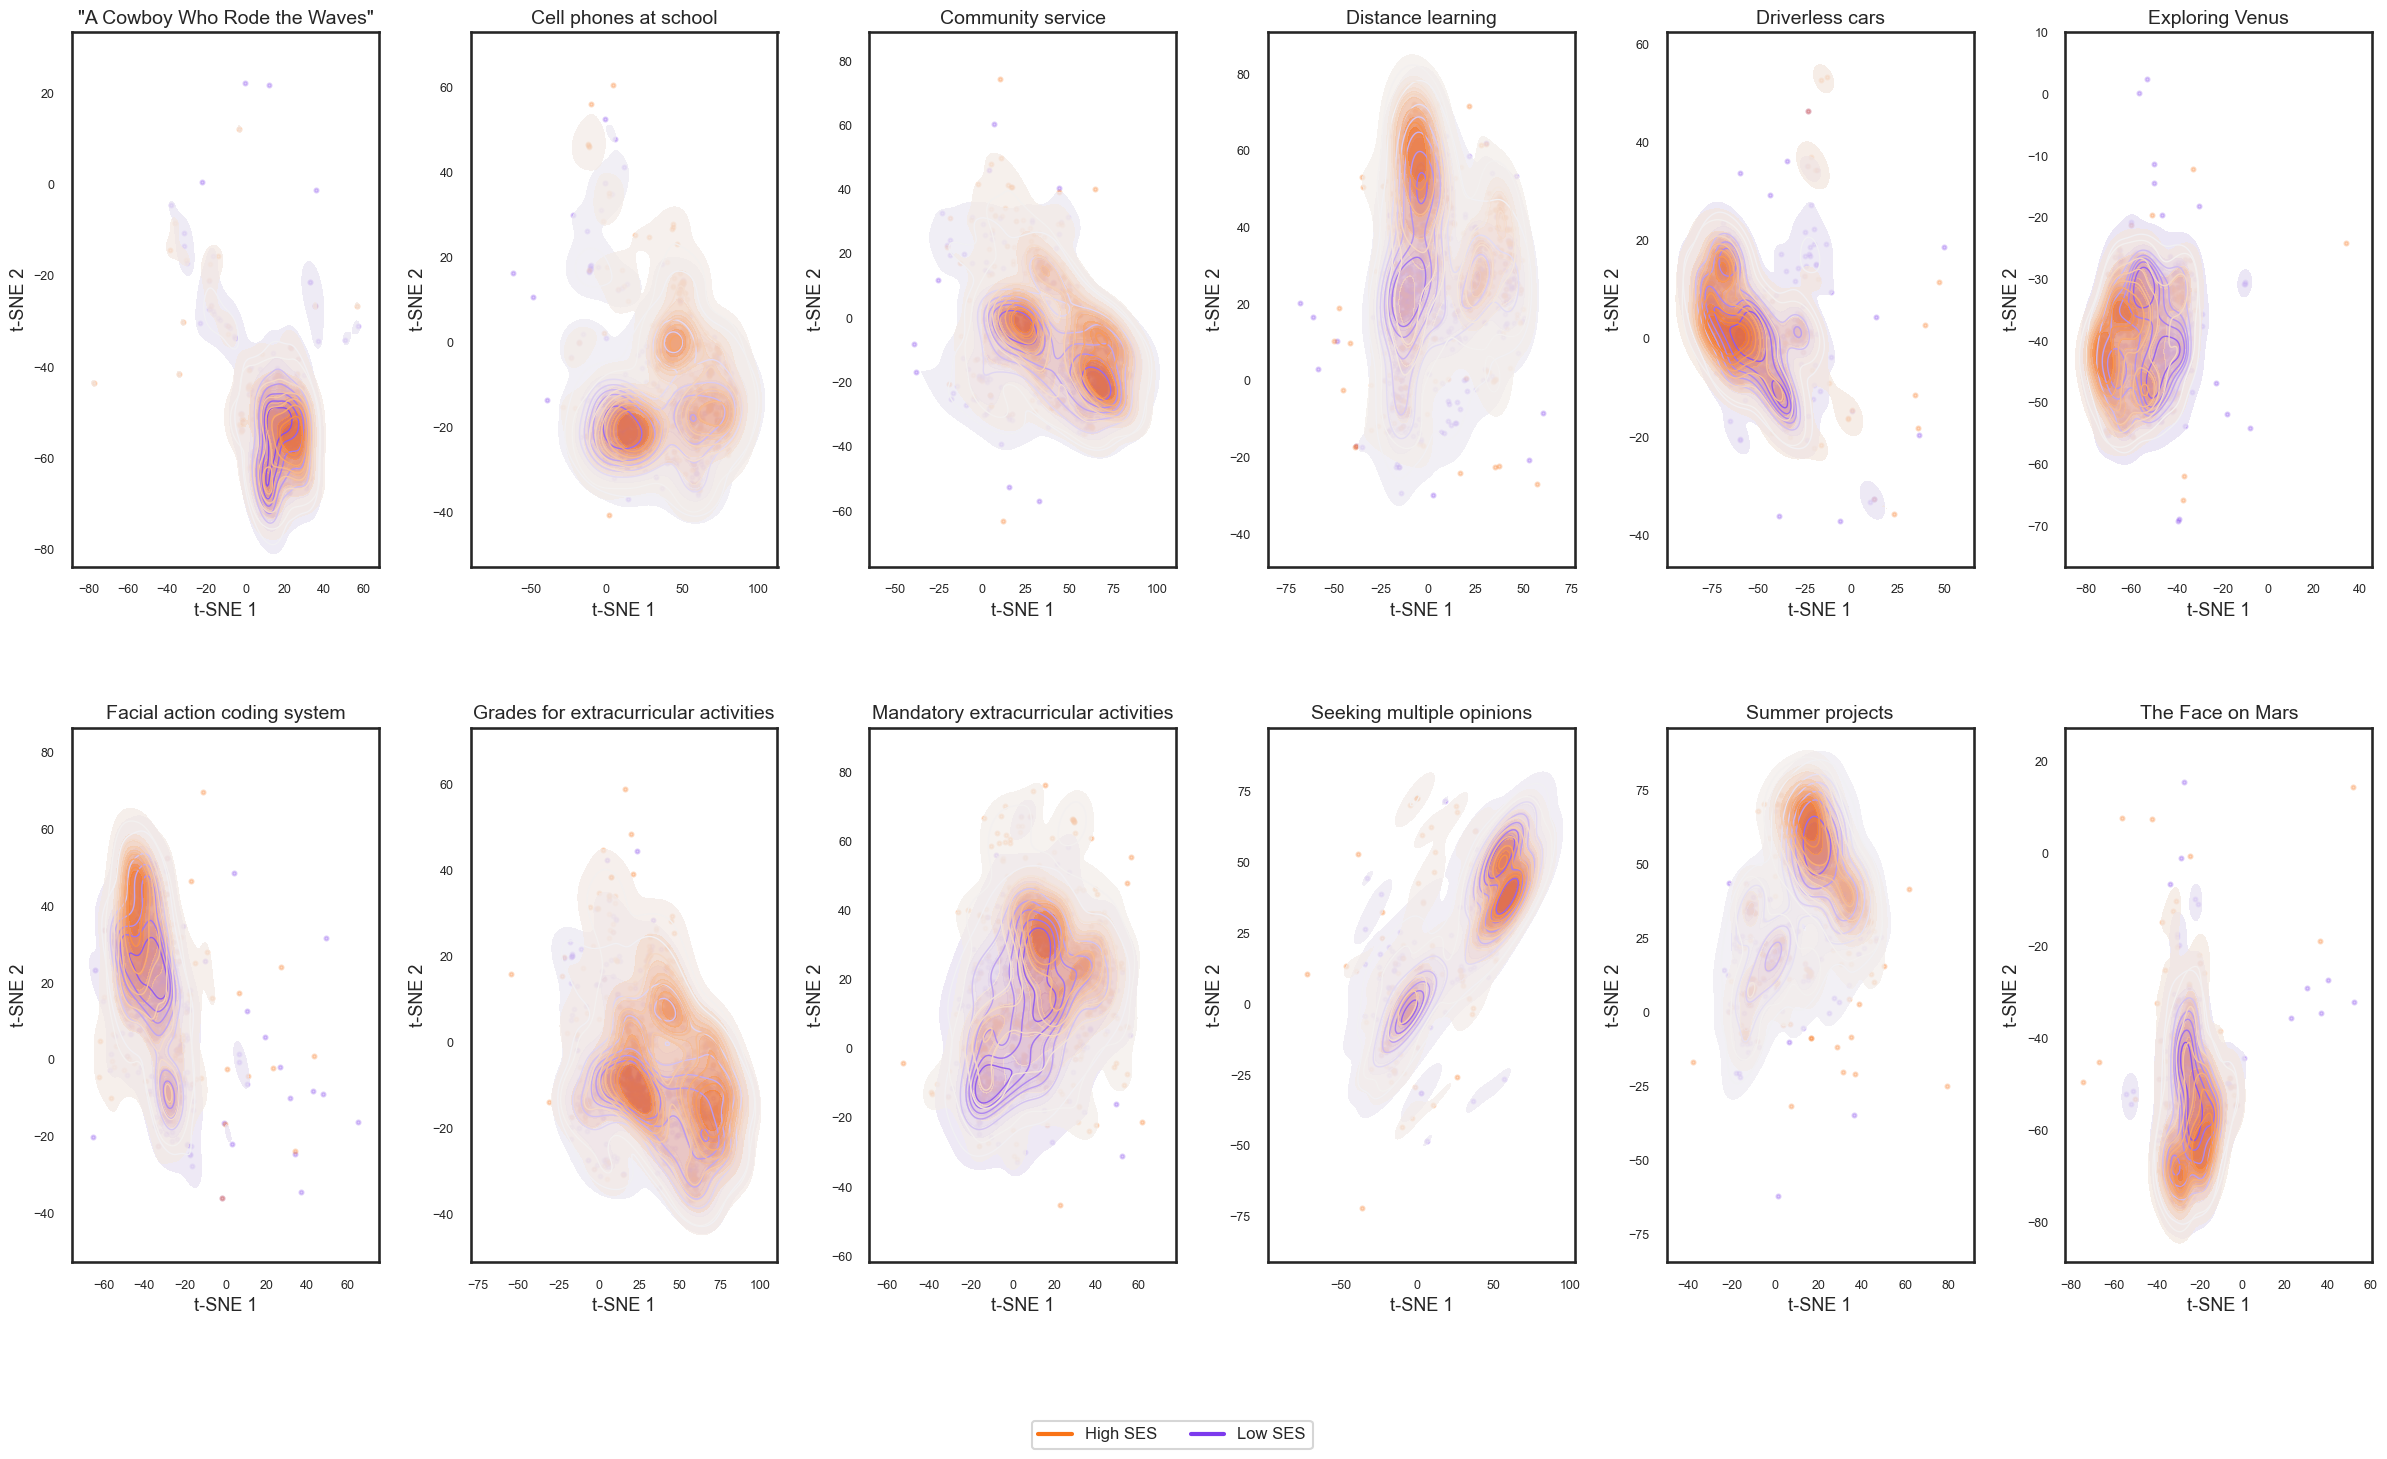

In [16]:
plot_tsne_grid(
    df_tsne,
    rows=2,
    cols=6,
    save_path=f"{SAVE_DIR}/tsne_grid.pdf",
    title_fs=14,
    label_fs=13,
    legend_fs=12, 
    wspace=0.30,
    hspace=0.30,

    legend_loc="lower center",
    legend_bbox=(0.5, -0.05)
)


----

# Rewrites Visualizations

### Distribution of predicted scores (Low x High)

In [17]:
# --- Overlayed histogram helper ---
def overlay_hist(df, col, label, save_name=None, save_dir=None):
    plt.figure(figsize=FIG_SIZE)
    bins = np.linspace(1, 6, 100)

    # High SES
    sns.histplot(
        data=df[df["low_SES"] == 0],
        x=col,
        bins=bins,
        stat="density", 
        element="step",
        fill=True,
        alpha=0.35,
        color="tab:blue",
        label="High SES",
        common_norm=False
    )

    # Low SES
    sns.histplot(
        data=df[df["low_SES"] == 1],
        x=col,
        bins=bins,
        stat="density",  
        element="step",
        fill=True,
        alpha=0.35,
        color="tab:orange",
        label="Low SES",
        common_norm=False
    )

    plt.xlim(1, 6)
    plt.xlabel(f"Predicted Essay Score ({label})")
    plt.ylabel("Density") 
    plt.legend()
    plt.tight_layout()

    if save_name:
        plt.savefig(SAVE_DIR + f"{save_name}.png", dpi=300)

    plt.show()
    plt.close()

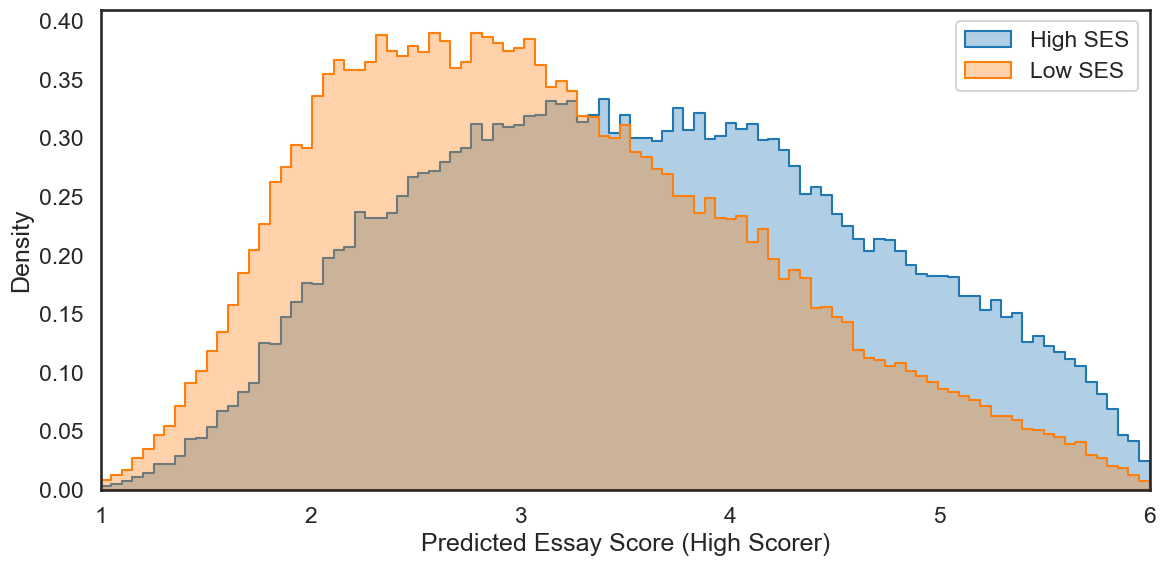

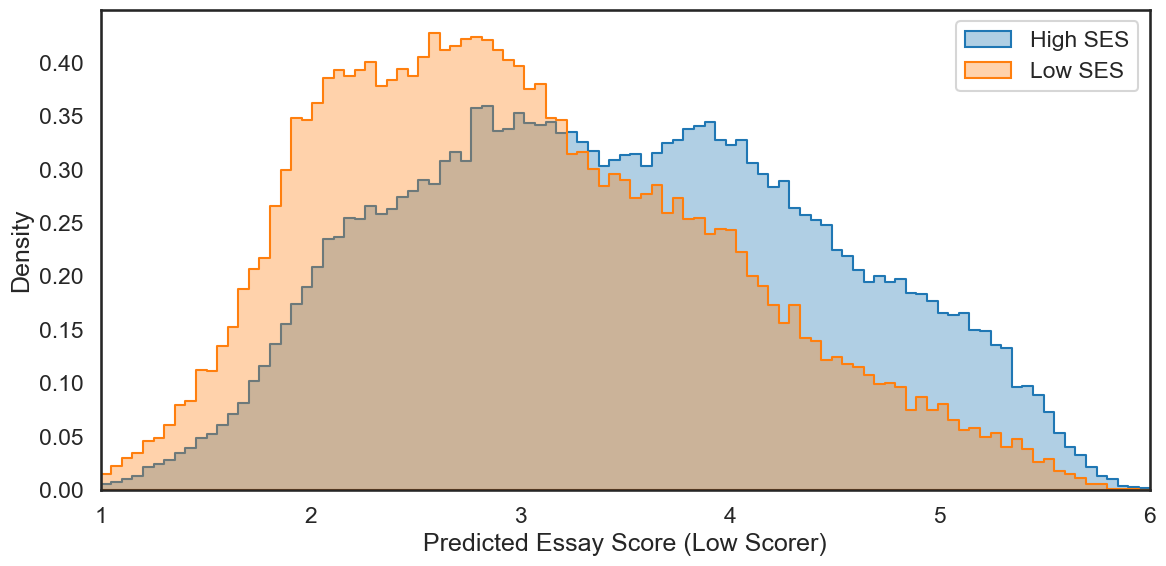

In [18]:
# --- Plots ---
overlay_hist(results_df, col="score_high_full", label="High Scorer", save_name="predicted_score_high_scorer", save_dir=SAVE_DIR)
overlay_hist(results_df, col="score_low_full",  label="Low Scorer", save_name="predicted_score_low_scorer", save_dir=SAVE_DIR)

### Share of explained variability R^2 - different scorers (Full x Emb x Style)

In [19]:
# --- Define model types ---
model_cols = ["full", "style", "emb"]

# --- Compute R² for Low SES scorer ---
r2_low = {
    m: r2_score(df_low_scorer["holistic_essay_score"], df_low_scorer[f"xgb_oof_pred_x_{m}"])
    for m in model_cols
}

# --- Compute R² for High SES scorer ---
r2_high = {
    m: r2_score(df_high_scorer["holistic_essay_score"], df_high_scorer[f"xgb_oof_pred_x_{m}"])
    for m in model_cols
}

# --- Build plotting dataframe ---
plot_df = pd.DataFrame({
    "Feature": ["Full", "Full", "Style", "Style", "Emb", "Emb"],
    "SES":     ["High", "Low",  "High",  "Low",   "High", "Low"],
    "R2": [
        r2_high["full"],  r2_low["full"],
        r2_high["style"], r2_low["style"],
        r2_high["emb"],   r2_low["emb"]
    ]
})

# --- Plot ---
fig, ax = plt.subplots(figsize=FIG_SIZE)

sns.barplot(
    data=plot_df,
    x="Feature",
    y="R2",
    hue="SES",
    palette={"High": "#1f77b4", "Low": "#ff7f0e"},
    ax=ax
)

ax.set_ylabel("R² (Explained Variability)")
ax.set_xlabel("Feature Type")
ax.set_ylim(0, 1)
ax.grid(axis="y", linestyle=":", alpha=0.3)

# Add bar labels
for c in ax.containers:
    ax.bar_label(c, fmt="%.3f", padding=3, fontsize=9)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}explained_variability.png", dpi=300)
plt.show()

NameError: name 'df_low_scorer' is not defined

### Comparison Original vs GPT rewrites

In [ ]:
df_viz

,Unnamed: 0,essay_id,k,true_score,low_SES,race_white,gender_male,prompt_name,grade_level,cv_fold,...,score_high_emb,score_low_emb,score_high_taaled,score_low_taaled,score_high_taaco,score_low_taaco,score_high_taassc,score_low_taassc,correction_factor,score_diff
0,0,0d717d5d-2734-4d00-98ab-8527a4d664f7,0,3,False,True,True,Summer projects,11.0,3,...,3.848287,3.718099,3.815336,3.503736,3.569814,3.745397,3.833944,3.900998,1.0,0.998649
1,1,48c17d01-a804-4ead-933c-b8cb18777a21,0,4,False,False,True,Summer projects,11.0,1,...,3.379174,3.548945,3.863222,3.703911,4.162063,3.825643,3.840232,3.497867,1.0,-0.260019
2,2,a20e23d7-2ad8-4656-a055-1fe5bbd35ecb,0,4,False,True,True,Summer projects,11.0,4,...,3.998368,3.851926,4.701632,4.711694,5.371764,4.993152,4.924241,5.019535,1.0,0.987003
3,3,f60f0f95-0182-4d83-a385-0c03cdbae761,0,4,False,False,False,Summer projects,11.0,2,...,4.619034,4.593761,4.583718,4.099163,4.635283,4.419876,4.542449,4.473258,1.0,0.593962
4,4,03ded759-6591-4d30-aa47-b45a5cc48815,0,3,True,False,True,Summer projects,11.0,1,...,4.545832,4.627963,4.023148,3.787030,3.568487,3.738469,3.926355,4.186929,1.0,1.088375
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
137090,139855,ff6069a8-9dba-4e93-8274-1bfad7eaa305,6,6,False,True,False,Seeking multiple opinions,8.0,1,...,4.936129,4.174436,5.433322,4.834185,5.622563,5.041197,5.730722,5.332886,1.0,-0.326695
137091,139856,7dbc91de-8cd3-4240-96b7-5f11e546b994,6,4,True,False,False,Seeking multiple opinions,8.0,1,...,4.440789,3.541054,3.944215,2.638706,3.270592,2.598117,3.529898,4.086452,1.0,0.464259
137092,139857,6fd87219-966b-4da4-b1b4-64d933a6d98a,6,4,False,False,True,Seeking multiple opinions,8.0,1,...,5.161642,4.595370,4.327888,4.384185,3.666918,3.416157,5.479279,4.751966,1.0,1.344970
137093,139858,ea638341-1419-4317-8b5a-2e903de406e5,6,4,True,False,False,Seeking multiple opinions,8.0,2,...,5.079499,4.312588,3.345300,2.848981,3.190899,3.179158,4.245917,3.282160,1.0,0.607870


/var/folders/xh/h3br85cj4574lr6srgb5hrgw0000gn/T/ipykernel_70380/3918576878.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


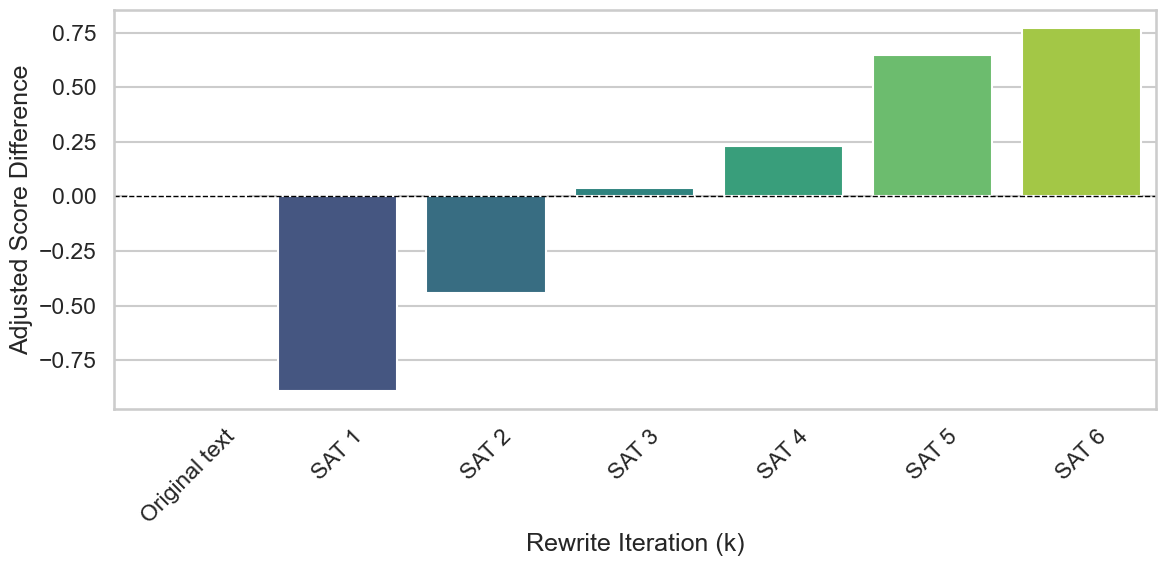

In [ ]:
# --- Compute adjusted score differences ---
df_viz = results_df.copy()

CORRECTION_INDEX = {
    0: 1.0,
    1: 1.0,
    2: 1.0,
    3: 1.0,
    4: 1.0,
    5: 1.0,
    6: 1.0
}

df_viz["correction_factor"] = df_viz["k"].map(CORRECTION_INDEX)
df_viz["score_diff"] = (
    df_viz["score_high_full"] - df_viz["true_score"]
) * df_viz["correction_factor"]

diff_by_k = (
    df_viz
    .groupby("k", as_index=False)["score_diff"]
    .mean()
)

diff_by_k["label"] = diff_by_k["k"].map(K_LABELS)

# --- Plot ---
plt.figure(figsize=FIG_SIZE)

sns.barplot(
    data=diff_by_k,
    x="label",
    y="score_diff",
    palette="viridis"
)

plt.xlabel("Rewrite Iteration (k)")
plt.ylabel("Adjusted Score Difference")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(f"{SAVE_DIR}/score_diff_by_k.pdf")
plt.show()


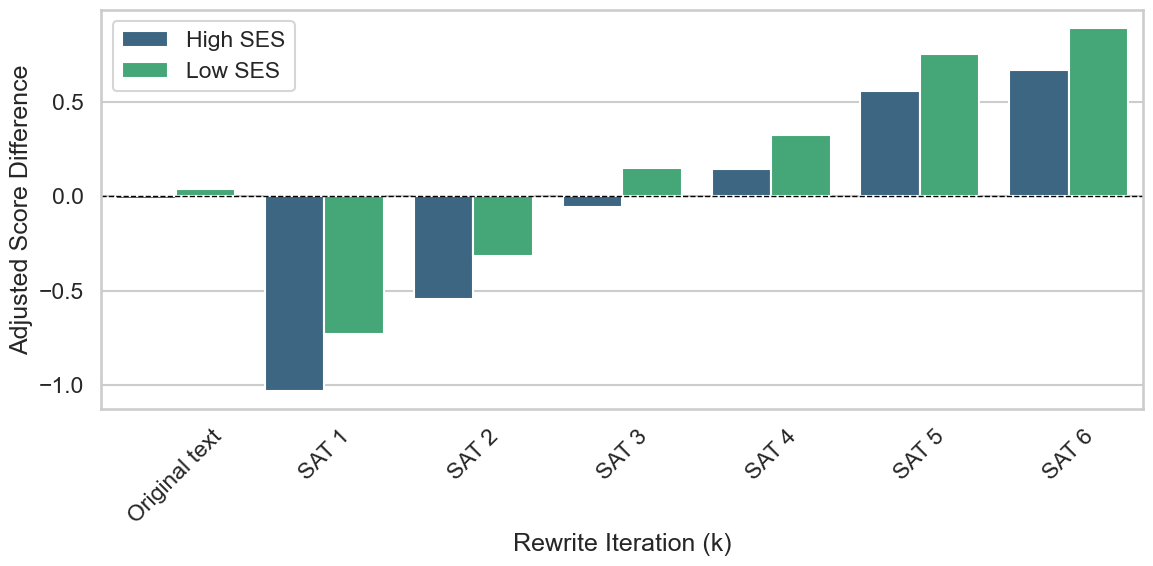

In [ ]:
# --- Compute adjusted score differences, split by SES ---
df_viz = results_df.copy()

CORRECTION_INDEX = {k: 1.0 for k in range(7)}  # same as your dict, shorter

df_viz["correction_factor"] = df_viz["k"].map(CORRECTION_INDEX)
df_viz["score_diff"] = (df_viz["score_high_full"] - df_viz["true_score"]) * df_viz["correction_factor"]

# Make a nice SES label
df_viz["ses_group"] = df_viz["low_SES"].map({False: "High SES", True: "Low SES"})

# Average within k x SES group
diff_by_k_ses = (
    df_viz
    .groupby(["k", "ses_group"], as_index=False)["score_diff"]
    .mean()
)

diff_by_k_ses["label"] = diff_by_k_ses["k"].map(K_LABELS)

# --- Plot ---
plt.figure(figsize=FIG_SIZE)

sns.barplot(
    data=diff_by_k_ses,
    x="label",
    y="score_diff",
    hue="ses_group",
    palette="viridis"
)

plt.xlabel("Rewrite Iteration (k)")
plt.ylabel("Adjusted Score Difference")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.xticks(rotation=45)
plt.legend(title="")
plt.tight_layout()

plt.savefig(f"{SAVE_DIR}/score_diff_by_k__by_ses.png", dpi=300)
plt.show()

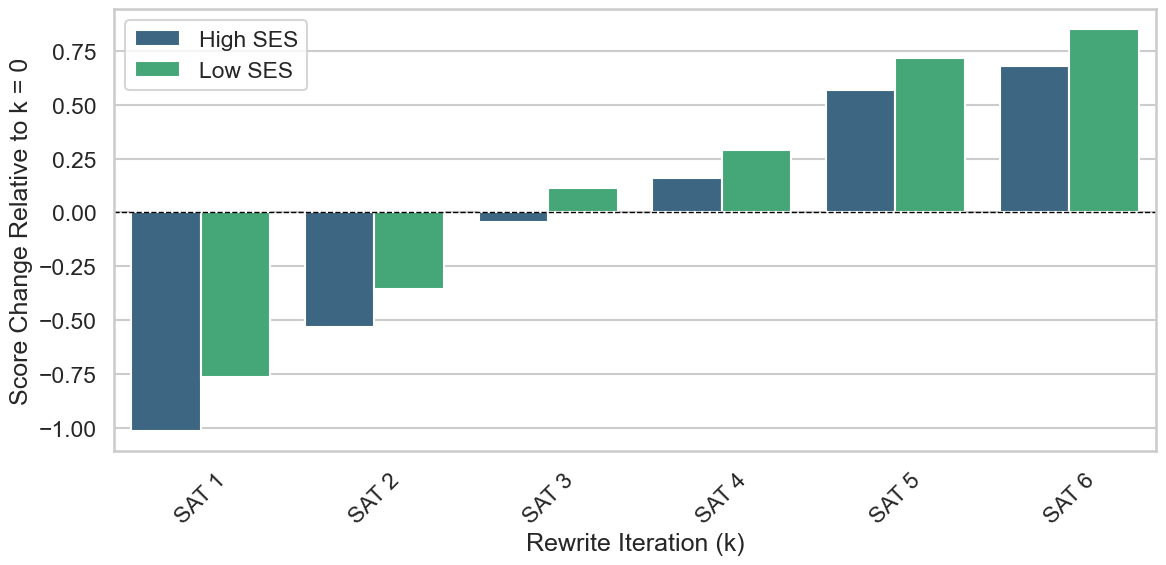

In [ ]:
# --- Compute score differences relative to k=0, split by SES ---
df_viz = results_df.copy()

# SES label
df_viz["ses_group"] = df_viz["low_SES"].map({False: "High SES", True: "Low SES"})

# 1) Extract k=0 scores
baseline = (
    df_viz[df_viz["k"] == 0]
    [["essay_id", "score_high_full"]]
    .rename(columns={"score_high_full": "score_k0"})
)

# 2) Merge baseline back to all k
df_viz = df_viz.merge(
    baseline,
    on="essay_id",
    how="left"
)

# 3) Compute difference relative to k=0
df_viz["score_diff"] = df_viz["score_high_full"] - df_viz["score_k0"]

# Optional: drop k=0 (difference is mechanically zero)
df_viz = df_viz[df_viz["k"] > 0]

# 4) Average within k x SES
diff_by_k_ses = (
    df_viz
    .groupby(["k", "ses_group"], as_index=False)["score_diff"]
    .mean()
)

diff_by_k_ses["label"] = diff_by_k_ses["k"].map(K_LABELS)

plt.figure(figsize=FIG_SIZE)

sns.barplot(
    data=diff_by_k_ses,
    x="label",
    y="score_diff",
    hue="ses_group",
    palette="viridis"
)

plt.xlabel("Rewrite Iteration (k)")
plt.ylabel("Score Change Relative to k = 0")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.xticks(rotation=45)
plt.legend(title="")
plt.tight_layout()

plt.savefig(f"{SAVE_DIR}/score_diff_vs_k0__by_ses.png", dpi=300)
plt.show()

In [ ]:
df

,Unnamed: 0,essay_id,k,true_score,low_SES,race_white,gender_male,prompt_name,grade_level,cv_fold,...,score_low_style,score_high_emb,score_low_emb,score_high_taaled,score_low_taaled,score_high_taaco,score_low_taaco,score_high_taassc,score_low_taassc,ses_group
0,0,0d717d5d-2734-4d00-98ab-8527a4d664f7,0,3,False,True,True,Summer projects,11.0,3,...,3.859234,3.848287,3.718099,3.815336,3.503736,3.569814,3.745397,3.833944,3.900998,H
1,1,48c17d01-a804-4ead-933c-b8cb18777a21,0,4,False,False,True,Summer projects,11.0,1,...,3.401469,3.379174,3.548945,3.863222,3.703911,4.162063,3.825643,3.840232,3.497867,H
2,2,a20e23d7-2ad8-4656-a055-1fe5bbd35ecb,0,4,False,True,True,Summer projects,11.0,4,...,5.121298,3.998368,3.851926,4.701632,4.711694,5.371764,4.993152,4.924241,5.019535,H
3,3,f60f0f95-0182-4d83-a385-0c03cdbae761,0,4,False,False,False,Summer projects,11.0,2,...,4.464949,4.619034,4.593761,4.583718,4.099163,4.635283,4.419876,4.542449,4.473258,H
4,4,03ded759-6591-4d30-aa47-b45a5cc48815,0,3,True,False,True,Summer projects,11.0,1,...,4.266418,4.545832,4.627963,4.023148,3.787030,3.568487,3.738469,3.926355,4.186929,L
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
137090,139855,ff6069a8-9dba-4e93-8274-1bfad7eaa305,6,6,False,True,False,Seeking multiple opinions,8.0,1,...,5.323286,4.936129,4.174436,5.433322,4.834185,5.622563,5.041197,5.730722,5.332886,H
137091,139856,7dbc91de-8cd3-4240-96b7-5f11e546b994,6,4,True,False,False,Seeking multiple opinions,8.0,1,...,3.550207,4.440789,3.541054,3.944215,2.638706,3.270592,2.598117,3.529898,4.086452,L
137092,139857,6fd87219-966b-4da4-b1b4-64d933a6d98a,6,4,False,False,True,Seeking multiple opinions,8.0,1,...,4.573213,5.161642,4.595370,4.327888,4.384185,3.666918,3.416157,5.479279,4.751966,H
137093,139858,ea638341-1419-4317-8b5a-2e903de406e5,6,4,True,False,False,Seeking multiple opinions,8.0,2,...,3.883788,5.079499,4.312588,3.345300,2.848981,3.190899,3.179158,4.245917,3.282160,L


In [ ]:
df[df['k']!=1]

,Unnamed: 0,essay_id,k,true_score,low_SES,race_white,gender_male,prompt_name,grade_level,cv_fold,...,score_low_style,score_high_emb,score_low_emb,score_high_taaled,score_low_taaled,score_high_taaco,score_low_taaco,score_high_taassc,score_low_taassc,ses_group
0,0,0d717d5d-2734-4d00-98ab-8527a4d664f7,0,3,False,True,True,Summer projects,11.0,3,...,3.859234,3.848287,3.718099,3.815336,3.503736,3.569814,3.745397,3.833944,3.900998,H
1,1,48c17d01-a804-4ead-933c-b8cb18777a21,0,4,False,False,True,Summer projects,11.0,1,...,3.401469,3.379174,3.548945,3.863222,3.703911,4.162063,3.825643,3.840232,3.497867,H
2,2,a20e23d7-2ad8-4656-a055-1fe5bbd35ecb,0,4,False,True,True,Summer projects,11.0,4,...,5.121298,3.998368,3.851926,4.701632,4.711694,5.371764,4.993152,4.924241,5.019535,H
3,3,f60f0f95-0182-4d83-a385-0c03cdbae761,0,4,False,False,False,Summer projects,11.0,2,...,4.464949,4.619034,4.593761,4.583718,4.099163,4.635283,4.419876,4.542449,4.473258,H
4,4,03ded759-6591-4d30-aa47-b45a5cc48815,0,3,True,False,True,Summer projects,11.0,1,...,4.266418,4.545832,4.627963,4.023148,3.787030,3.568487,3.738469,3.926355,4.186929,L
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
137090,139855,ff6069a8-9dba-4e93-8274-1bfad7eaa305,6,6,False,True,False,Seeking multiple opinions,8.0,1,...,5.323286,4.936129,4.174436,5.433322,4.834185,5.622563,5.041197,5.730722,5.332886,H
137091,139856,7dbc91de-8cd3-4240-96b7-5f11e546b994,6,4,True,False,False,Seeking multiple opinions,8.0,1,...,3.550207,4.440789,3.541054,3.944215,2.638706,3.270592,2.598117,3.529898,4.086452,L
137092,139857,6fd87219-966b-4da4-b1b4-64d933a6d98a,6,4,False,False,True,Seeking multiple opinions,8.0,1,...,4.573213,5.161642,4.595370,4.327888,4.384185,3.666918,3.416157,5.479279,4.751966,H
137093,139858,ea638341-1419-4317-8b5a-2e903de406e5,6,4,True,False,False,Seeking multiple opinions,8.0,2,...,3.883788,5.079499,4.312588,3.345300,2.848981,3.190899,3.179158,4.245917,3.282160,L


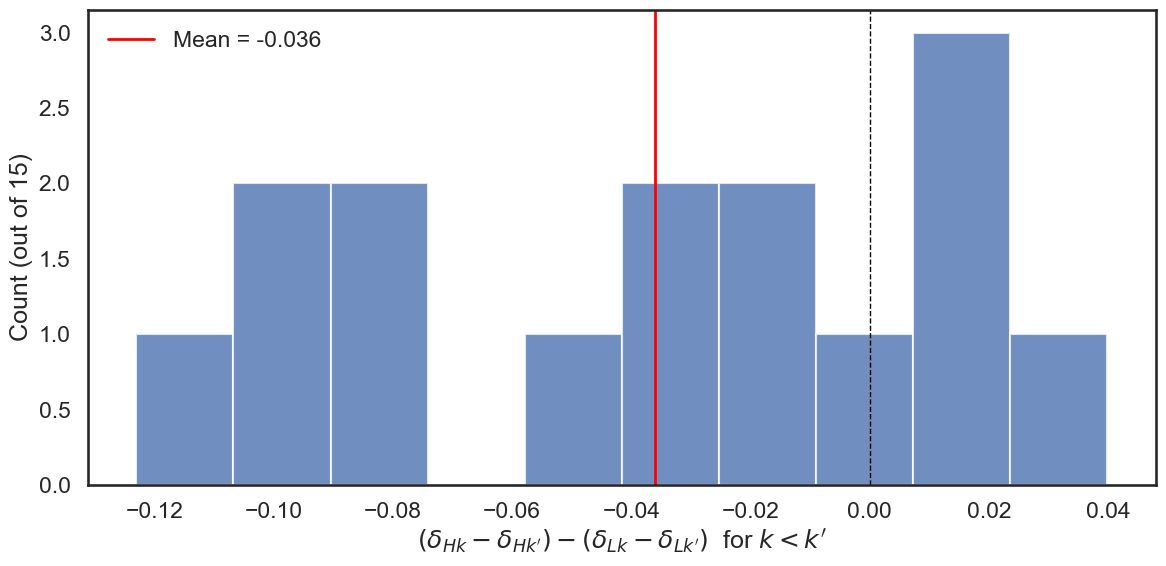

Mean of pairwise SES-gap differences: -0.0360


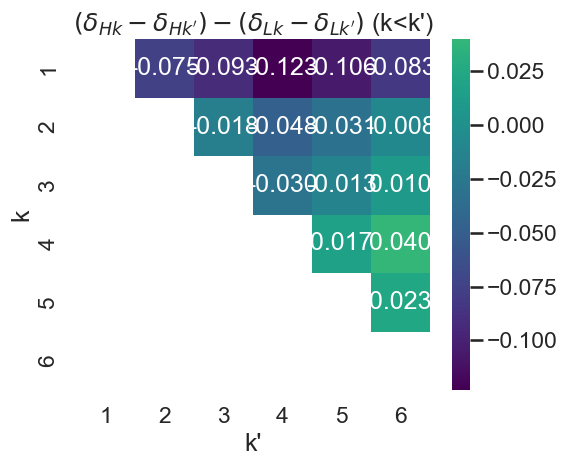

delta_H (k=1..6): [-1.01743926 -0.53165646 -0.04517334  0.15929635  0.56931003  0.68254076]
delta_L (k=1..6): [-0.76426223 -0.3535236   0.11486972  0.28939677  0.71615765  0.8525418 ]
Saved: ../../output//ses_pairwise_diff_distribution_15.png
Saved: ../../output//ses_pairwise_diff_heatmap_upper.png
Saved: ../../output//ses_pairwise_diff_values_15.csv


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------
# CONFIG (edit if needed)
# ----------------------------
K_COL     = "k"
SES_COL   = "low_SES"          # True = Low SES, False = High SES
SCORE_COL = "score_high_full"  # s_ik
K_MIN, K_MAX = 1, 6

SAVE_DIR = SAVE_DIR            # assumes defined
FIG_SIZE = FIG_SIZE            # assumes defined; else set e.g. (10, 4)

# ----------------------------
# DATA
# ----------------------------
df = results_df.copy()
# df = df[df['k']!=1]
df["ses_group"] = df[SES_COL].map({False: "H", True: "L"})

# Step 1: mean score by (SES,k): E[s_ik | SES]
mean_s = (
    df.groupby(["ses_group", K_COL], as_index=False)[SCORE_COL]
      .mean()
      .rename(columns={SCORE_COL: "mean_score"})
)

# Baseline means E[s_i0 | SES]
mean_s0 = (
    mean_s[mean_s[K_COL] == 0][["ses_group", "mean_score"]]
    .rename(columns={"mean_score": "mean_score_k0"})
)

# Merge baseline into all k
mean_s = mean_s.merge(mean_s0, on="ses_group", how="left")

# Step 2: delta_{SES,k} = E[s_ik - s_i0 | SES]
mean_s["delta"] = mean_s["mean_score"] - mean_s["mean_score_k0"]

delta = mean_s[mean_s[K_COL].between(K_MIN, K_MAX)].copy()

# Table: rows=SES, cols=k, values=delta_{SES,k}
delta_tbl = delta.pivot(index="ses_group", columns=K_COL, values="delta")

ks = list(range(K_MIN, K_MAX + 1))
delta_H = delta_tbl.loc["H", ks].to_numpy()
delta_L = delta_tbl.loc["L", ks].to_numpy()

# Step 3: compute 6x6 matrix for convenience
val_mat = (delta_H[:, None] - delta_H[None, :]) - (delta_L[:, None] - delta_L[None, :])

# Step 4: keep only unordered pairs once: (k,k') with k < k'
vals = []
for i, k in enumerate(ks):
    for j, kp in enumerate(ks):
        if k < kp:
            vals.append({
                "k": k,
                "k_prime": kp,
                "value": val_mat[i, j]
            })

vals = pd.DataFrame(vals)  # 15 rows

# ----------------------------
# PLOT 1: distribution of the 15 values
# ----------------------------
# ----------------------------
# PLOT: distribution of the 15 values + mean
# ----------------------------
vals_mean = vals["value"].mean()

plt.figure(figsize=(FIG_SIZE if isinstance(FIG_SIZE, tuple) else (10, 4)))
plt.hist(vals["value"].values, bins=min(10, len(vals)), alpha=0.8)

# zero reference
plt.axvline(0, color="black", linestyle="--", linewidth=1)

# mean line
plt.axvline(vals_mean, color="red", linestyle="-", linewidth=2, label=f"Mean = {vals_mean:.3f}")

plt.xlabel(r"$(\delta_{Hk}-\delta_{Hk'}) - (\delta_{Lk}-\delta_{Lk'})$  for $k<k'$")
plt.ylabel("Count (out of 15)")
plt.legend(frameon=False)
plt.tight_layout()

plt.savefig(f"{SAVE_DIR}/ses_pairwise_diff_distribution_15_with_mean.png", dpi=300)
plt.show()

print(f"Mean of pairwise SES-gap differences: {vals_mean:.4f}")

# ----------------------------
# PLOT 2: triangular heatmap (upper triangle only)
# ----------------------------
heat = pd.DataFrame(val_mat, index=ks, columns=ks)
mask = np.tril(np.ones_like(heat, dtype=bool))  # mask diagonal + lower triangle

plt.figure(figsize=(6, 5))
sns.heatmap(heat, mask=mask, annot=True, fmt=".3f", center=0, cmap="viridis")
plt.xlabel("k'")
plt.ylabel("k")
plt.title(r"$(\delta_{Hk}-\delta_{Hk'}) - (\delta_{Lk}-\delta_{Lk'})$ (k<k')")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/ses_pairwise_diff_heatmap_upper.png", dpi=300)
plt.show()

# ----------------------------
# Save the 15 values
# ----------------------------
vals.to_csv(f"{SAVE_DIR}/ses_pairwise_diff_values_15.csv", index=False)

print("delta_H (k=1..6):", delta_H)
print("delta_L (k=1..6):", delta_L)
print(f"Saved: {SAVE_DIR}/ses_pairwise_diff_distribution_15.png")
print(f"Saved: {SAVE_DIR}/ses_pairwise_diff_heatmap_upper.png")
print(f"Saved: {SAVE_DIR}/ses_pairwise_diff_values_15.csv")


In [ ]:
# ill do the one oat the top, with, with standard errors and bootstrap, wirte the mean and ci for the mean in the white part

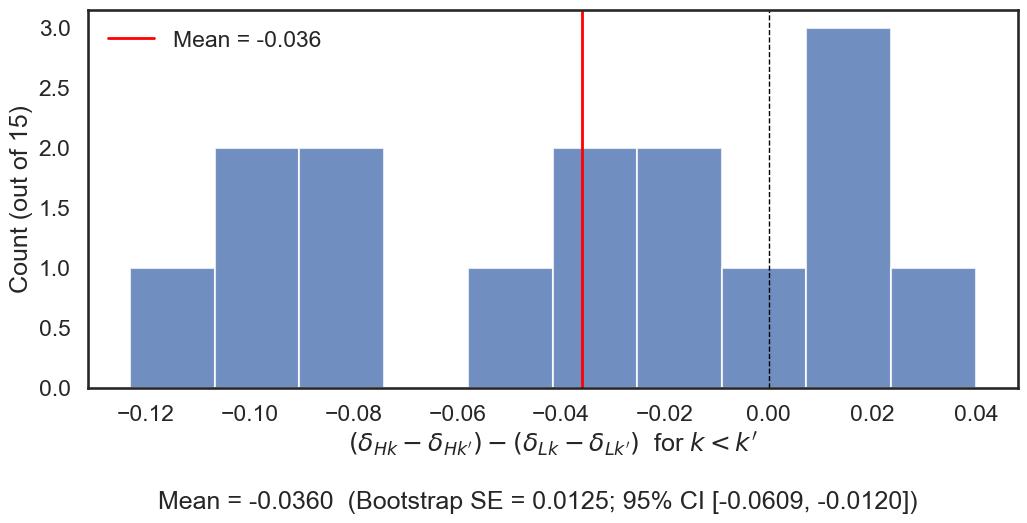

Mean: -0.035979
Bootstrap SE (B=100000): 0.012515
95% bootstrap CI: [-0.060851, -0.011963]
Saved: ../../output//ses_pairwise_diff_distribution_15_with_mean_bootstrap.png


In [22]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Bootstrap mean + SE over the 15 values
# ----------------------------
x = vals["value"].to_numpy()
mean_hat = x.mean()

B = 100_000
rng = np.random.default_rng(123)

boot_means = rng.choice(x, size=(B, len(x)), replace=True).mean(axis=1)
boot_se = boot_means.std(ddof=1)
ci_lo, ci_hi = np.quantile(boot_means, [0.025, 0.975])

# ----------------------------
# Plot distribution + mean line + text below with mean(SE)
# ----------------------------
fig, ax = plt.subplots(figsize=(FIG_SIZE if isinstance(FIG_SIZE, tuple) else (10, 4)))

ax.hist(x, bins=min(10, len(x)), alpha=0.8)
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.axvline(mean_hat, color="red", linestyle="-", linewidth=2, label=f"Mean = {mean_hat:.3f}")

ax.set_xlabel(r"$(\delta_{Hk}-\delta_{Hk'}) - (\delta_{Lk}-\delta_{Lk'})$  for $k<k'$")
ax.set_ylabel("Count (out of 15)")
ax.legend(frameon=False)

# Add space at bottom and write the summary line below the plot
fig.subplots_adjust(bottom=0.25)
fig.text(
    0.5, 0.06,
    f"Mean = {mean_hat:.4f}  (Bootstrap SE = {boot_se:.4f}; 95% CI [{ci_lo:.4f}, {ci_hi:.4f}])",
    ha="center", va="center"
)

out_path = f"{SAVE_DIR}/ses_pairwise_diff_distribution_15_with_mean_bootstrap.png"
fig.savefig(out_path, dpi=300)
plt.show()

print(f"Mean: {mean_hat:.6f}")
print(f"Bootstrap SE (B={B}): {boot_se:.6f}")
print(f"95% bootstrap CI: [{ci_lo:.6f}, {ci_hi:.6f}]")
print(f"Saved: {out_path}")


In [12]:
regression_df = results_df[results_df['k']!=0]


In [ ]:
regression_df.columns

low_SES k k*lowSes

Index(['Unnamed: 0', 'essay_id', 'k', 'true_score', 'low_SES', 'race_white',
       'gender_male', 'prompt_name', 'grade_level', 'cv_fold',
       'score_high_full', 'score_low_full', 'score_high_style',
       'score_low_style', 'score_high_emb', 'score_low_emb',
       'score_high_taaled', 'score_low_taaled', 'score_high_taaco',
       'score_low_taaco', 'score_high_taassc', 'score_low_taassc'],
      dtype='object')

In [24]:
import statsmodels.formula.api as smf


In [ ]:

res = smf.ols(
    "score_high_full ~ C(k) + C(k):low_SES + C(essay_id)",
    data=regression_df
).fit(cov_type="cluster", cov_kwds={"groups": regression_df["essay_id"]})

In [25]:
from pyfixest.estimation import feols
import pandas as pd

d = regression_df[["score_high_full", "k", "low_SES", "essay_id"]].dropna().copy()

d["low_SES"] = d["low_SES"].astype(int)          # 0/1 is best here
d["k"] = d["k"].astype(str)                      # or pd.Categorical(d["k"])

res = feols(
    "score_high_full ~ i(k, ref='6')  + i(k, low_SES, ref='6') | essay_id",
    data=d,
    vcov={"CRV3": "essay_id"}
)

print(res.summary())

KeyboardInterrupt: 

### Distribution of predicted scores (Low x High) 
* Style 
* Embedding
* TAASSC
* TAACO
* TAALED
* PREPROC

In [ ]:
df_plot = results_df.copy()
df_plot["SES"] = np.where(df_plot["low_SES"] == 1, "Low SES", "High SES")

for evals in ["style", "emb", "taaled", "taaco", "taassc"]:
    overlay_hist(df_plot, col=f"score_high_{evals}", label=f"High Scorer {evals}")
    overlay_hist(df_plot, col=f"score_low_{evals}",  label=f"Low Scorer {evals}")

### Predicted scores (High x Low) - Includes STD and mean lines

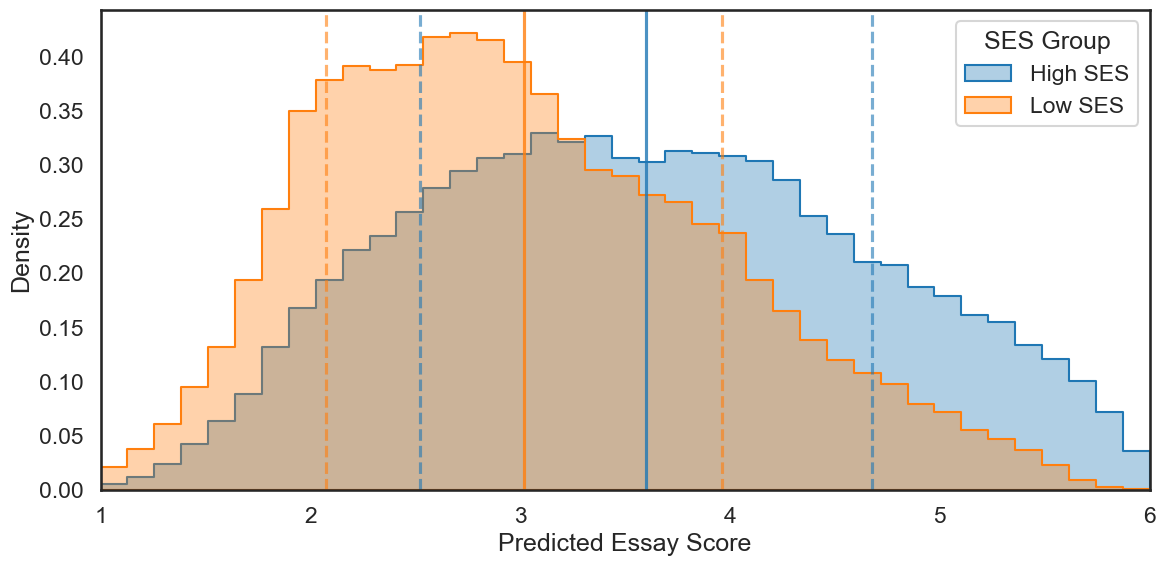

In [57]:
# Overlayed predicted-score histograms with mean±std lines (by SES)
bins = np.linspace(1, 6, 40)

hi_mask = results_df["low_SES"] == 0
lo_mask = ~hi_mask

x_hi = results_df.loc[hi_mask, "score_high_full"].dropna()
x_lo = results_df.loc[lo_mask, "score_low_full"].dropna()

plt.figure(figsize=FIG_SIZE)

sns.histplot(x=x_hi, bins=bins, stat="density", element="step",
             fill=True, alpha=0.35, color="tab:blue", label="High SES")
sns.histplot(x=x_lo, bins=bins, stat="density", element="step",
             fill=True, alpha=0.35, color="tab:orange", label="Low SES")

m_hi, s_hi = x_hi.mean(), x_hi.std(ddof=1)
m_lo, s_lo = x_lo.mean(), x_lo.std(ddof=1)

plt.axvline(m_hi, color="tab:blue", alpha=0.8)
plt.axvline(m_hi+s_hi, color="tab:blue", linestyle="--", alpha=0.6)
plt.axvline(m_hi-s_hi, color="tab:blue", linestyle="--", alpha=0.6)

plt.axvline(m_lo, color="tab:orange", alpha=0.8)
plt.axvline(m_lo+s_lo, color="tab:orange", linestyle="--", alpha=0.6)
plt.axvline(m_lo-s_lo, color="tab:orange", linestyle="--", alpha=0.6)

plt.xlim(1, 6)
plt.xlabel("Predicted Essay Score")
plt.ylabel("Density")
plt.legend(title="SES Group")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}predicted_scores_std.png", dpi=300)
plt.show()

### Distribution of rewrites predicted score - high ranker

In [58]:
# Stable color map by label
_BASE = sns.color_palette("tab10", n_colors=len(K_LABELS))
COLOR_MAP = {K_LABELS[k]: _BASE[i] for i, k in enumerate(sorted(K_LABELS))}

def plot_k_kde(results_df, pred_col, out_png, scorer_note):
    df = results_df[[pred_col, "k"]].dropna().copy()
    df["k"] = df["k"].astype(int)
    df["k_label"] = df["k"].map(K_LABELS)
    df = df[df["k_label"].notna()]

    present = [K_LABELS[k] for k in sorted(df["k"].unique()) if k in K_LABELS]
    pal = [COLOR_MAP[l] for l in present]

    plt.figure(figsize=FIG_SIZE if "FIG_SIZE" in globals() else (8, 6))

    ax = sns.kdeplot(
        data=df,
        x=pred_col,
        hue="k_label",
        hue_order=present,
        palette=pal,
        common_norm=False,
        linewidth=2,
        clip=(1, 6),
    )
    ax.set_xlim(1, 6)
    ax.set_xlabel(f"Predicted Essay Score {scorer_note}")
    ax.set_ylabel("Density")

    # --- Fix existing legend instead of creating new one ---
    leg = ax.get_legend()
    if leg is not None:
        leg.set_title("Version (k)")
        leg.set_bbox_to_anchor((1.02, 1))
        leg._loc = 2  # 'upper left'

    plt.tight_layout()
    plt.savefig(out_png, dpi=300)
    plt.show()

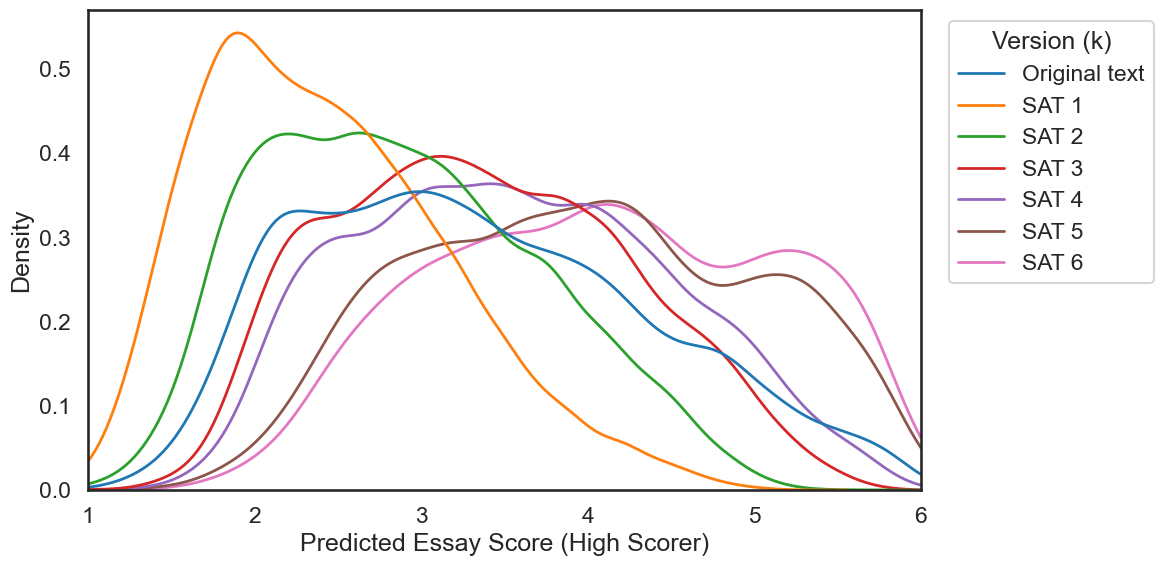

In [59]:
plot_k_kde(results_df, "score_high_full", f"{SAVE_DIR}predicted_scores_k_high_density.png", "(High Scorer)")

### Distribution of rewrites predicted score - low ranker

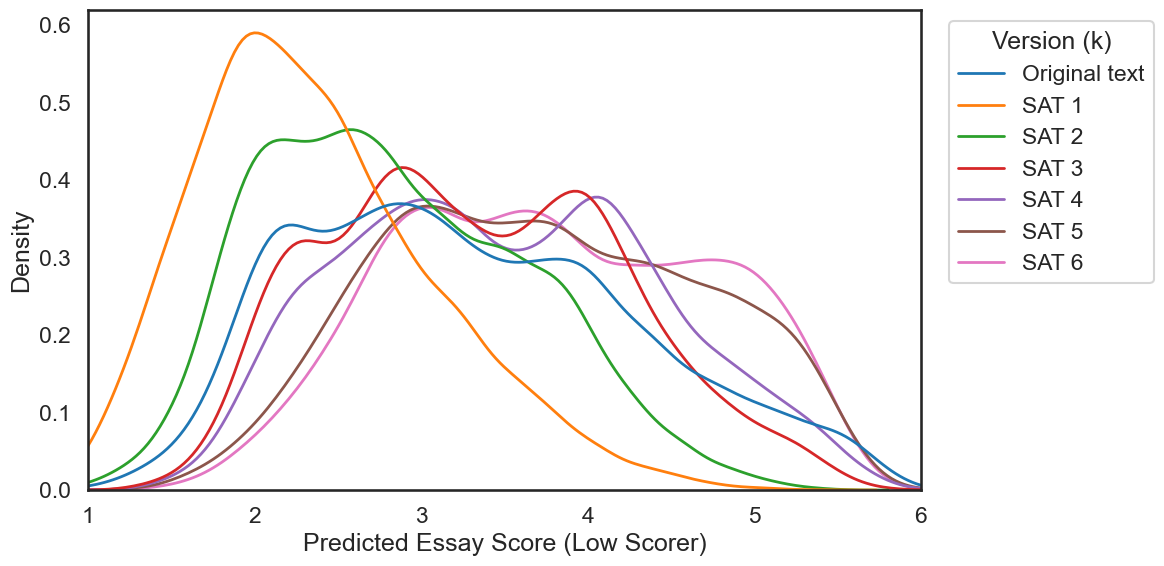

In [60]:
plot_k_kde(results_df, "score_low_full",  f"{SAVE_DIR}predicted_scores_k_low_density.png",  "(Low Scorer)")

### Bar graph - mean prediction (rewrite X SES)

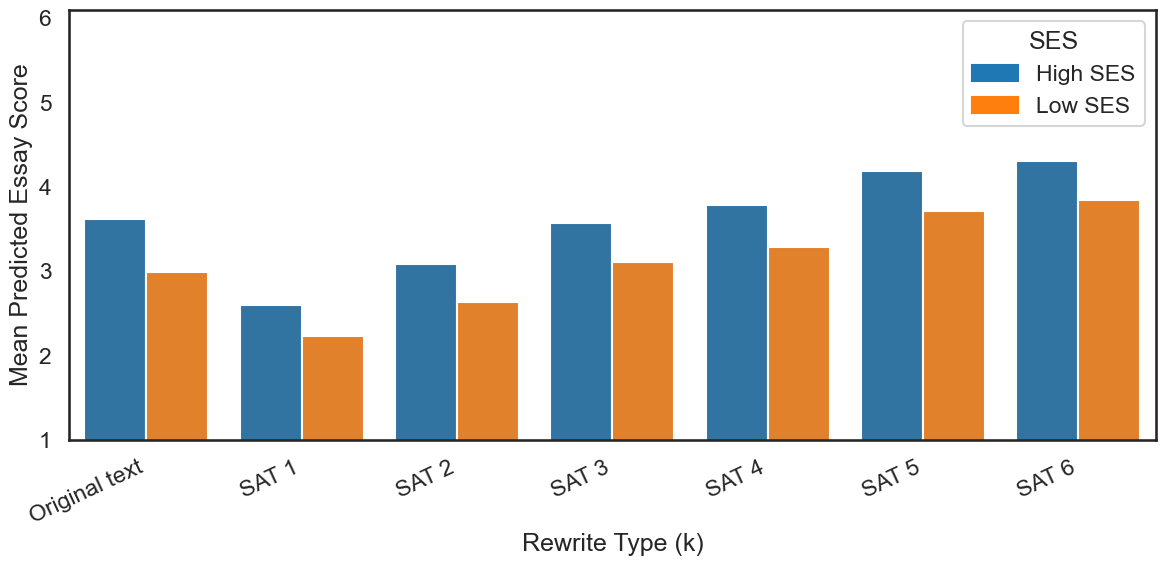

In [61]:
# --- Prep ---
df = results_df.dropna(subset=["score_high_full", "low_SES", "k"]).copy()
df["k_label"] = df["k"].map(K_LABELS)

# --- Aggregate: mean and standard error by k × SES ---
agg = (
    df.groupby(["k_label", "low_SES"])["score_high_full"]
    .agg(["mean", "count", "std"])
    .reset_index()
)
agg["se"] = agg["std"] / np.sqrt(agg["count"])

# --- Plot ---
plt.figure(figsize=FIG_SIZE)
sns.barplot(
    data=agg,
    x="k_label",
    y="mean",
    hue="low_SES",
    order=list(K_LABELS.values()),
    palette={0: "tab:blue", 1: "tab:orange"},
    capsize=0.15,
    err_kws={"color": "black", "linewidth": 1.5},
    legend=True
)

# --- Styling ---
plt.xlabel("Rewrite Type (k)")
plt.ylabel("Mean Predicted Essay Score")
plt.xticks(rotation=25, ha="right")
plt.yticks(np.arange(1, 7, 1))
plt.ylim(1, 6.1)
plt.legend(
    handles=[
        mpatches.Patch(color="tab:blue", label="High SES"),
        mpatches.Patch(color="tab:orange", label="Low SES")
    ],
    title="SES",
    loc="upper right",
    frameon=True
)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}predicted_k_mean.png", dpi=300)
plt.show()

### Distribution of rewrites predicted score - only on style (high ranker)

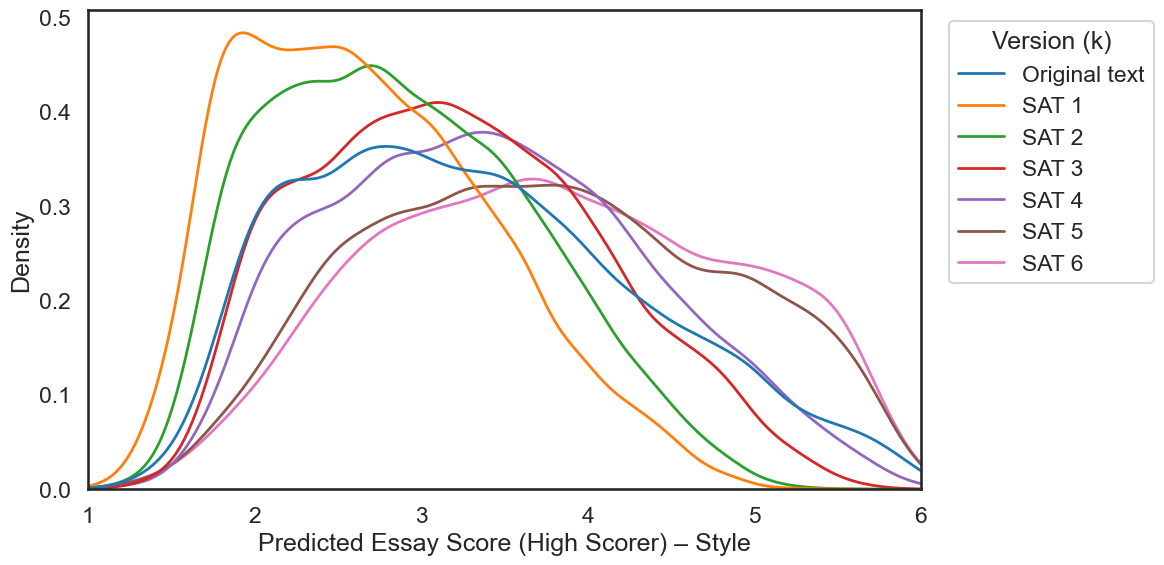

In [62]:
plot_k_kde(
    results_df,
    pred_col="score_high_style",
    out_png=f"{SAVE_DIR}predicted_scores_k_high_style_density.png",
    scorer_note="(High Scorer) – Style"
)

---- 

# Fixed Effects / Decomposition Visualizations

### Fixed Effect distribution - (empircal Bayes Correction)

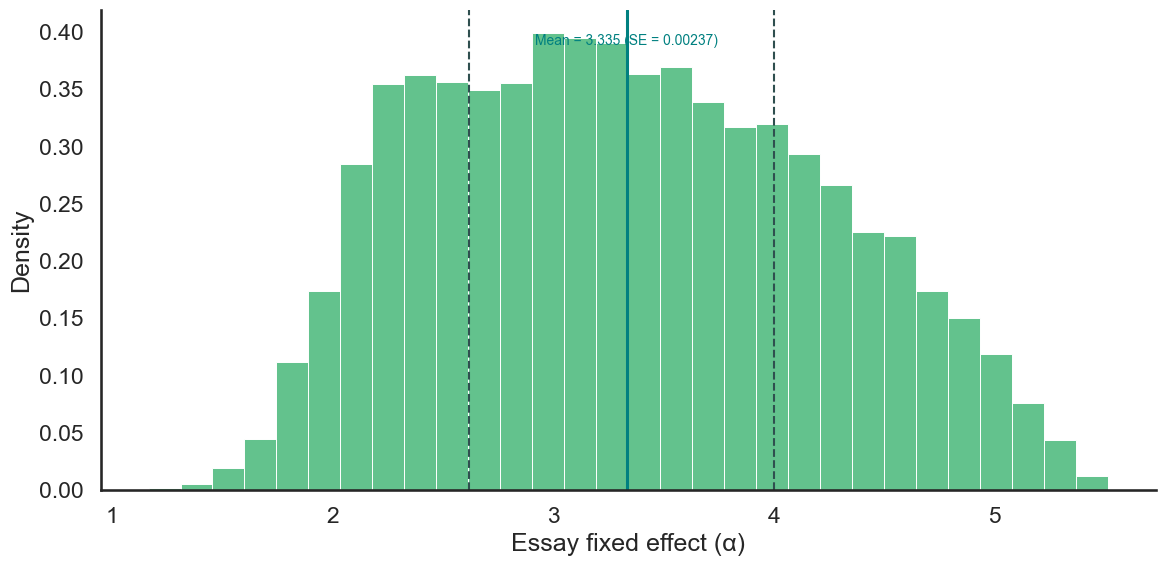

In [63]:
# Drop missing fixed effects (empirical Bayes correction)
x = df_decomp["fe_essay"].dropna()

# Compute stats
mean = x.mean()
se = x.std(ddof=1) / np.sqrt(len(x))
q1, q3 = np.percentile(x, [25, 75])

# --- Plot ---
plt.figure(figsize=FIG_SIZE)
sns.histplot(
    x,
    bins=30,
    color="mediumseagreen",
    stat="density",
    edgecolor="white",
    linewidth=0.7,
    alpha=0.8
)

# Quartile lines
plt.axvline(q1, color="darkslategray", linestyle="--", linewidth=1.5, label="Q1 / Q3")
plt.axvline(q3, color="darkslategray", linestyle="--", linewidth=1.5)

# Mean line (on top)
plt.axvline(mean, color="teal", linewidth=2.2, label="Mean")

# Text label
plt.text(mean, plt.ylim()[1]*0.95,
         f"Mean = {mean:.3f} (SE = {se:.5f})",
         ha="center", va="top", fontsize=10, color="teal")

# Labels and style
plt.xlabel("Essay fixed effect (α)")
plt.ylabel("Density")
sns.despine()
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}fixed_effect_distribution.png", dpi=300)
plt.show()


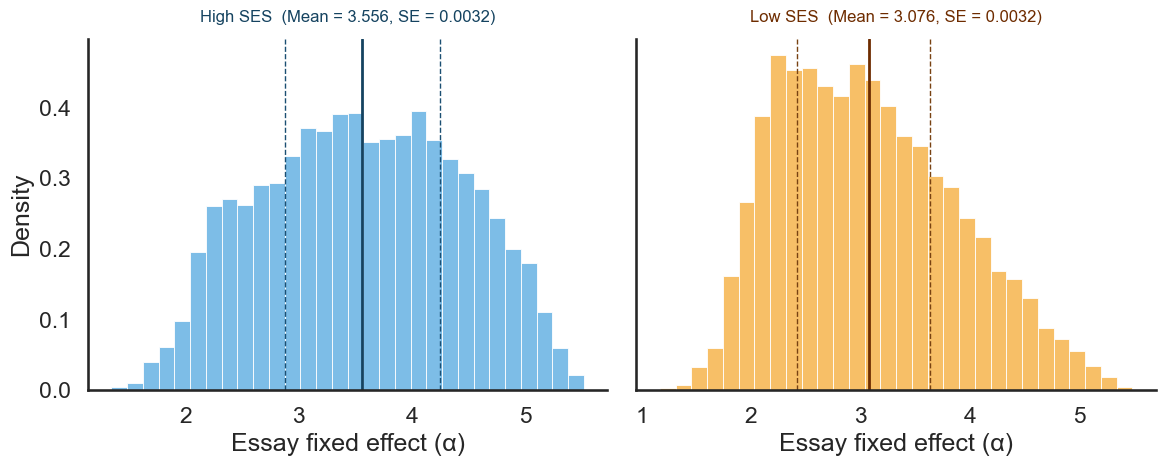

In [64]:
# Drop missing fixed effects
df_plot = df_decomp.dropna(subset=["fe_essay"])

# Split by SES
low_df  = df_plot[df_plot["low_SES"] == 1]["fe_essay"]
high_df = df_plot[df_plot["low_SES"] == 0]["fe_essay"]

# Helper to compute stats
def describe(x):
    return {
        "mean": x.mean(),
        "se": x.std(ddof=1) / np.sqrt(len(x)),
        "q1": np.percentile(x, 25),
        "q3": np.percentile(x, 75),
    }

stats_low  = describe(low_df)
stats_high = describe(high_df)

# --- Create side-by-side figure ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# ---------- HIGH SES ----------
sns.histplot(
    high_df, bins=30, stat="density",
    color="#5DADE2", edgecolor="white", linewidth=0.6, alpha=0.8, ax=axes[0]
)
axes[0].axvline(stats_high["q1"], color="#1B4F72", linestyle="--", linewidth=1)
axes[0].axvline(stats_high["q3"], color="#1B4F72", linestyle="--", linewidth=1)
axes[0].axvline(stats_high["mean"], color="#154360", linewidth=2)

axes[0].set_title(
    f"High SES  (Mean = {stats_high['mean']:.3f}, SE = {stats_high['se']:.4f})",
    fontsize=12, color="#154360", pad=12
)
axes[0].set_xlabel("Essay fixed effect (α)")
axes[0].set_ylabel("Density")

# ---------- LOW SES ----------
sns.histplot(
    low_df, bins=30, stat="density",
    color="#F5B041", edgecolor="white", linewidth=0.6, alpha=0.8, ax=axes[1]
)
axes[1].axvline(stats_low["q1"], color="#784212", linestyle="--", linewidth=1)
axes[1].axvline(stats_low["q3"], color="#784212", linestyle="--", linewidth=1)
axes[1].axvline(stats_low["mean"], color="#6E2C00", linewidth=2)

axes[1].set_title(
    f"Low SES  (Mean = {stats_low['mean']:.3f}, SE = {stats_low['se']:.4f})",
    fontsize=12, color="#6E2C00", pad=12
)
axes[1].set_xlabel("Essay fixed effect (α)")
axes[1].set_ylabel("")

# --- Styling ---
for ax in axes:
    sns.despine(ax=ax)
    ax.axhline(0, color="gray", lw=0.5)

# fig.suptitle("Distribution of Essay Fixed Effects (α) by SES Group", fontsize=14, y=1.04)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}fixed_effect_distribution_by_SES_dual.png", dpi=300, bbox_inches="tight")
plt.show()

----

### Style distribution - (empircal Bayes Correction)

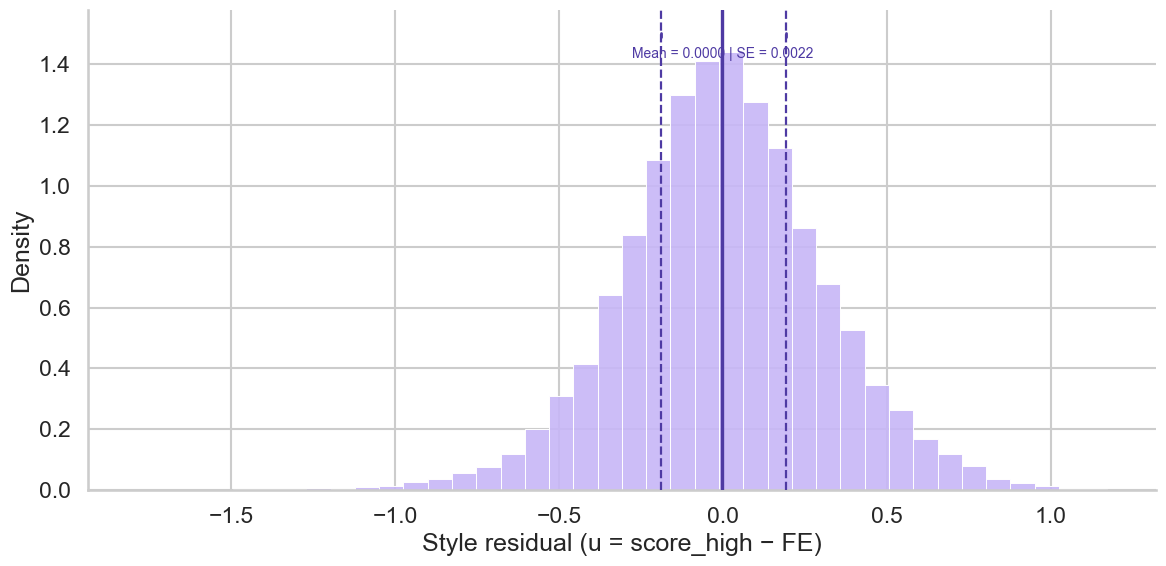

In [65]:
# --- Data (original essays only) ---
mask = (df_decomp["k"] == 0) & df_decomp["u"].notna()
u = df_decomp.loc[mask, "u"].astype(float)

# --- Stats ---
mean = u.mean()
q1, med, q3 = np.percentile(u, [25, 50, 75])
iqr = q3 - q1
se = u.std(ddof=1) / np.sqrt(len(u))  # standard error of the mean

plt.figure(figsize=FIG_SIZE)
sns.set_style("whitegrid")

# Histogram
sns.histplot(
    u, bins=40, stat="density",
    color="#C7B6F7", edgecolor="white", linewidth=0.7, alpha=0.9
)

# Quartile lines (visual guides only)
yl = plt.ylim()
plt.axvline(q1, color="#4E3AA3", linestyle="--", linewidth=1.6, zorder=3)
plt.axvline(q3, color="#4E3AA3", linestyle="--", linewidth=1.6, zorder=3)
plt.axvline(med, color="#4E3AA3", linewidth=2.4, zorder=4, label=f"SE = {se:.4f}")

# Tiny tick marks at top
top = yl[1]
for xline in (q1, med, q3):
    plt.plot([xline, xline], [top*0.985, top*0.995], color="#4E3AA3", linewidth=2, zorder=5, clip_on=False)

# --- Text annotation: now shows mean and SE ---
plt.text(
    mean, top*0.965,
    f"Mean = {mean:.4f} | SE = {se:.4f}",
    ha="center", va="top", fontsize=10, color="#4E3AA3"
)

# Labels / title
plt.xlabel("Style residual (u = score_high − FE)")
plt.ylabel("Density")
sns.despine()
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}style_distribution.png", dpi=300)
plt.show()

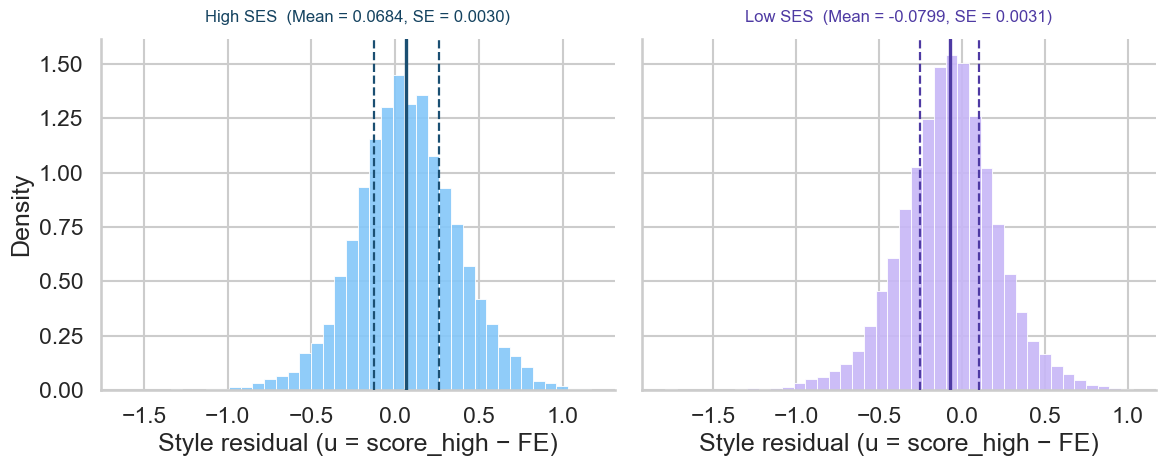

In [66]:
# --- Data (original essays only) ---
mask = (df_decomp["k"] == 0) & df_decomp["u"].notna()
df_u = df_decomp.loc[mask, ["low_SES", "u"]].astype(float)

# Split by SES
u_high = df_u[df_u["low_SES"] == 0]["u"]
u_low  = df_u[df_u["low_SES"] == 1]["u"]

# --- Helper for summary stats ---
def describe(x):
    return {
        "mean": x.mean(),
        "se": x.std(ddof=1) / np.sqrt(len(x)),
        "q1": np.percentile(x, 25),
        "med": np.percentile(x, 50),
        "q3": np.percentile(x, 75),
    }

stats_high = describe(u_high)
stats_low  = describe(u_low)

# --- Plot setup ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
sns.set_style("whitegrid")

# ---------- HIGH SES ----------
sns.histplot(
    u_high, bins=40, stat="density",
    color="#84C7F9", edgecolor="white", linewidth=0.6, alpha=0.9, ax=axes[0]
)
yl = axes[0].get_ylim()
for val, ls, lw in zip(
    [stats_high["q1"], stats_high["med"], stats_high["q3"]],
    ["--", "-", "--"],
    [1.6, 2.4, 1.6],
):
    axes[0].axvline(val, color="#1B4F72", linestyle=ls, linewidth=lw, zorder=3)
axes[0].set_title(
    f"High SES  (Mean = {stats_high['mean']:.4f}, SE = {stats_high['se']:.4f})",
    fontsize=12, color="#154360", pad=12
)
axes[0].set_xlabel("Style residual (u = score_high − FE)")
axes[0].set_ylabel("Density")

# ---------- LOW SES ----------
sns.histplot(
    u_low, bins=40, stat="density",
    color="#C7B6F7", edgecolor="white", linewidth=0.6, alpha=0.9, ax=axes[1]
)
yl = axes[1].get_ylim()
for val, ls, lw in zip(
    [stats_low["q1"], stats_low["med"], stats_low["q3"]],
    ["--", "-", "--"],
    [1.6, 2.4, 1.6],
):
    axes[1].axvline(val, color="#4E3AA3", linestyle=ls, linewidth=lw, zorder=3)
axes[1].set_title(
    f"Low SES  (Mean = {stats_low['mean']:.4f}, SE = {stats_low['se']:.4f})",
    fontsize=12, color="#4E3AA3", pad=12
)
axes[1].set_xlabel("Style residual (u = score_high − FE)")
axes[1].set_ylabel("")

# --- Style ---
for ax in axes:
    sns.despine(ax=ax)
    ax.axhline(0, color="gray", lw=0.5)

# fig.suptitle("Distribution of Style Residuals (u) by SES Group", fontsize=14, y=1.04)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}style_distribution_by_SES_dual.png", dpi=300, bbox_inches="tight")
plt.show()

---

### Decomposition Shares (All, By Gender, by Race, By question)
    * All of them (All, Gender, Race, Question)
    * All + Race + Gender
    * Different Prompts (Questions)

In [77]:
COMP_ORDER = ["content", "style", "others"]
COMP_COLORS = {"content": "#84C7F9", "style": "#C7B6F7", "others": "#B6E3C7"}

# ---------- Core: compute shares ----------
def _mean_mask(s, mask):
    s2 = s[mask & s.notna()]
    return float(s2.mean()) if len(s2) else np.nan

def _compute_decomp(df_sub):
    m_orig = (df_sub["k"] == 0)
    m_hi = m_orig & (df_sub["low_SES"] == 0) & df_sub["score_high_full"].notna()
    m_lo = m_orig & (df_sub["low_SES"] == 1) & df_sub["score_low_full"].notna()
    if not (m_hi.any() and m_lo.any()):
        return pd.Series({c: np.nan for c in COMP_ORDER})

    mean_hi = _mean_mask(df_sub["score_high_full"], m_hi)
    mean_lo = _mean_mask(df_sub["score_low_full"], m_lo)
    total_gap = mean_hi - mean_lo

    content_hi = _mean_mask(df_sub["fe_essay"], m_orig & (df_sub["low_SES"] == 0))
    content_lo = _mean_mask(df_sub["fe_essay"], m_orig & (df_sub["low_SES"] == 1))
    style_hi   = _mean_mask(df_sub["u"], m_orig & (df_sub["low_SES"] == 0))
    style_lo   = _mean_mask(df_sub["u"], m_orig & (df_sub["low_SES"] == 1))

    content_gap = content_hi - content_lo
    style_gap   = style_hi   - style_lo
    others_gap  = total_gap - (content_gap + style_gap)

    if not total_gap:
        return pd.Series({c: np.nan for c in COMP_ORDER})

    return pd.Series({
        "content": content_gap / total_gap,
        "style":   style_gap   / total_gap,
        "others":  others_gap  / total_gap
    })

# ---------- Add grade_level to compute_decomp_shares ----------
def compute_decomp_shares(df_decomp):
    df = df_decomp.copy()

    groups = {"All": df}

    # by race / gender
    for g in ["race_white", "gender_male"]:
        if g in df.columns:
            groups[f"{g}=True"]  = df[df[g] == True]
            groups[f"{g}=False"] = df[df[g] == False]

    # by grade_level (NEW)
    if "grade_level" in df.columns:
        for gl in sorted(df["grade_level"].dropna().unique()):
            groups[f"grade_level={gl}"] = df[df["grade_level"] == gl]

    # by prompt
    if "prompt_name" in df.columns:
        for p in sorted(df["prompt_name"].dropna().unique()):
            groups[f"Prompt: {p}"] = df[df["prompt_name"] == p]

    out = pd.DataFrame({k: _compute_decomp(v) for k, v in groups.items()}).T
    return out.reindex(columns=COMP_ORDER)


# ---------- Plot helpers ----------
def plot_stacked(df_shares, title=None, figsize=(10,6), xtick_rotation=0, save_path=None, label_map=None):
    """
    Draw stacked bar chart of decomposition shares with nicer labels.
    """
    if df_shares.empty:
        print("No data to plot.")
        return

    # Apply mapping for nicer labels (default: GROUP_LABELS)
    if label_map is None:
        label_map = GROUP_LABELS
    df_plot = df_shares.copy()
    df_plot.index = df_plot.index.map(lambda x: label_map.get(x, x))

    ax = df_plot[COMP_ORDER].plot(
        kind="bar",
        stacked=True,
        color=[COMP_COLORS[c] for c in COMP_ORDER],
        edgecolor="white",
        linewidth=0.6,
        figsize=figsize
    )
    ax.set_ylabel("Share of Total SES Gap")
    ax.set_xlabel("")
    ax.set_ylim(0, 1)
    ax.axhline(1, color="gray", lw=0.8, linestyle="--")
    if title:
        ax.set_title(title, pad=10)
    plt.xticks(rotation=xtick_rotation, ha="right" if xtick_rotation else "center")

    ax.legend(
        title="Component",
        loc="center left",
        bbox_to_anchor=(1.01, 0.5),
        frameon=False
    )
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


def plot_overview(decomp_shares, save_path=None, label_map=None):
    base = ["All", "race_white=True", "race_white=False", "gender_male=True", "gender_male=False"]
    grade_keys = sorted([i for i in decomp_shares.index if i.startswith("grade_level=")],key=lambda x: float(x.split("=")[1]))
    want = base + grade_keys  
    overview = decomp_shares.reindex(want).dropna(how="all")
    plot_stacked(overview, figsize=FIG_SIZE, xtick_rotation=45, save_path=save_path, label_map=label_map)


def plot_prompts(decomp_shares, save_path=None, label_map=None, figsize=(10,6)):
    prompts = decomp_shares.loc[decomp_shares.index.str.startswith("Prompt: ")].sort_index()
    h = max(5, 0.45 * len(prompts))
    plot_stacked(prompts, figsize=figsize, xtick_rotation=45, save_path=save_path, label_map=label_map)

In [78]:
# ---------- Group label mapping ----------
GROUP_LABELS = {
    "All": "All",
    "race_white=True": "White",
    "race_white=False": "Non-White",
    "gender_male=True": "Male",
    "gender_male=False": "Female",
    "grade_level=6.0": "Grade 6",
    "grade_level=8.0": "Grade 8",
    "grade_level=10.0": "Grade 10",
    "grade_level=11.0": "Grade 11",
}

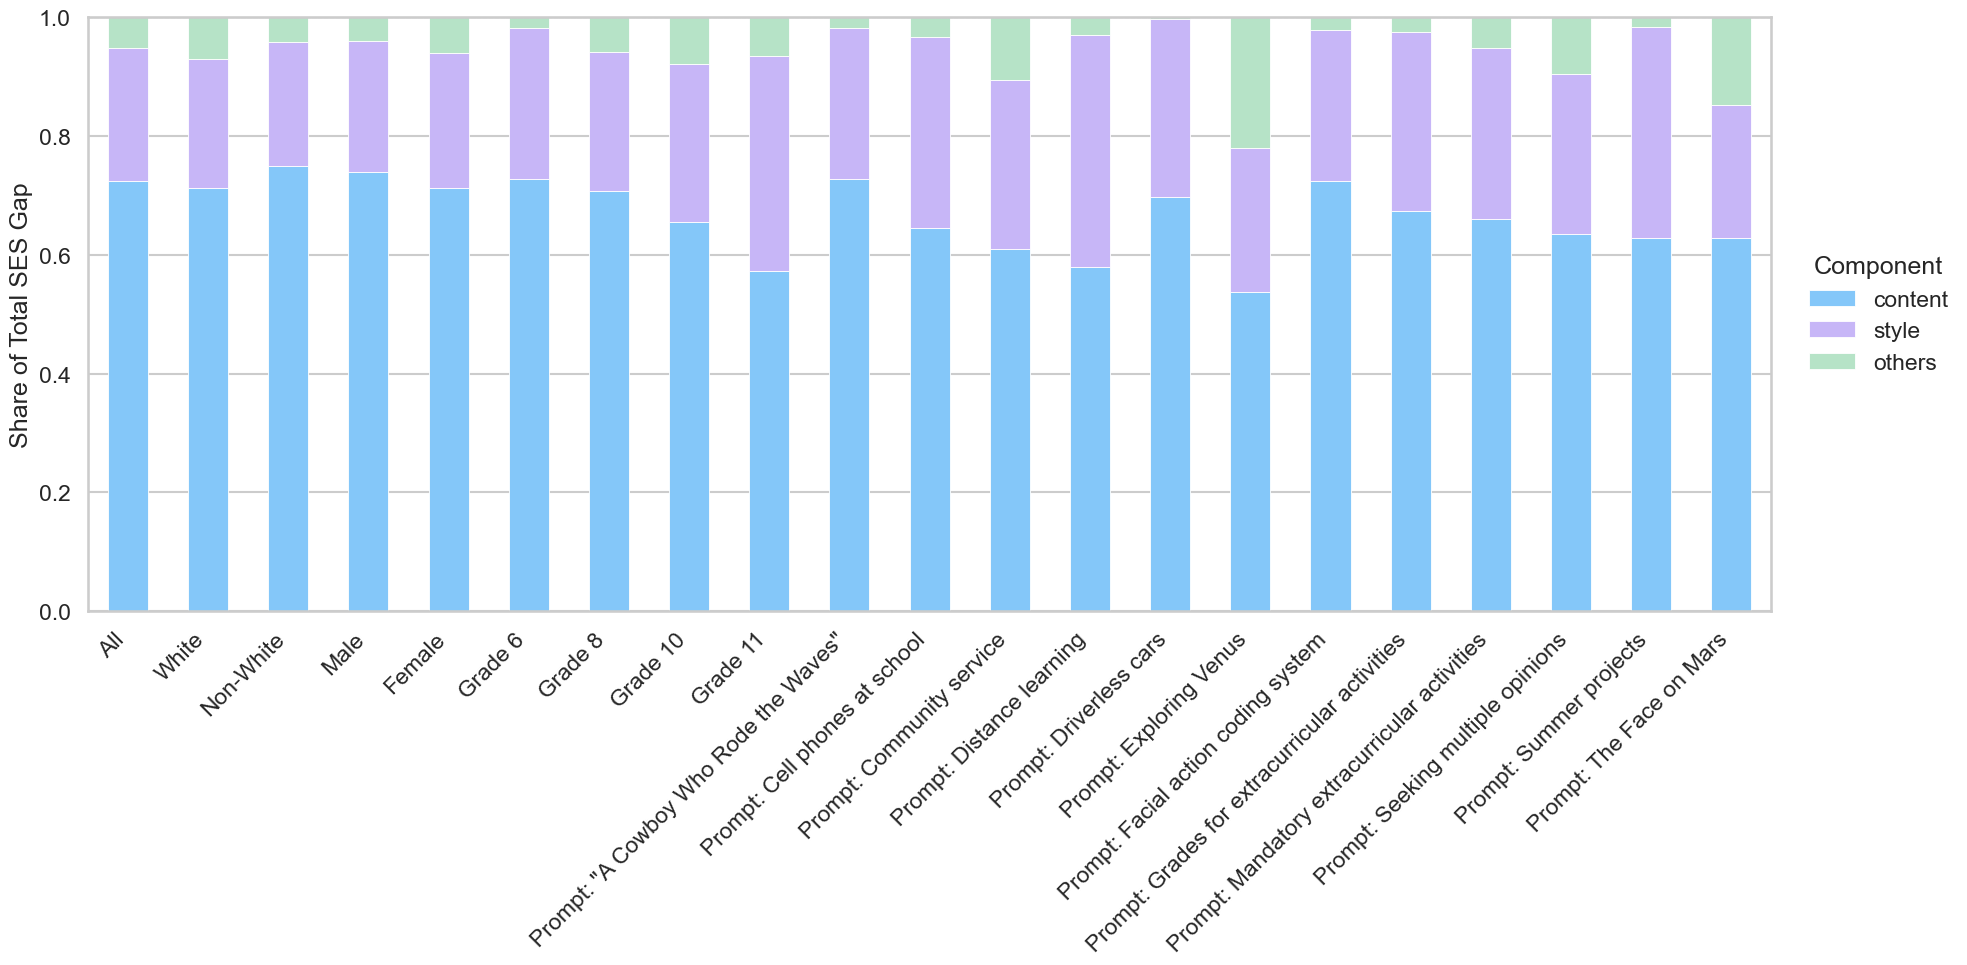

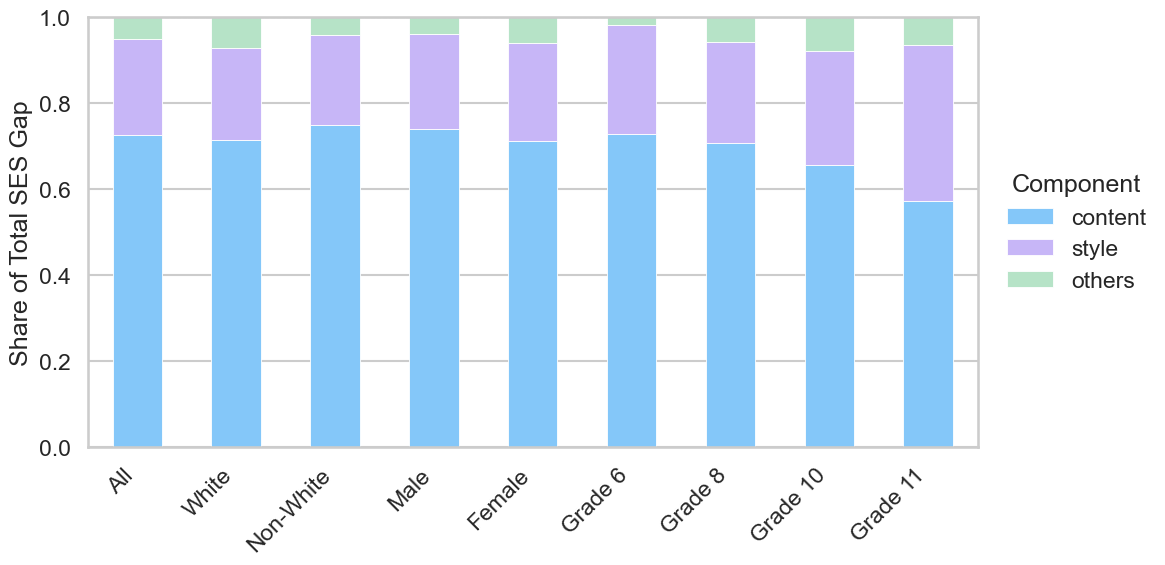

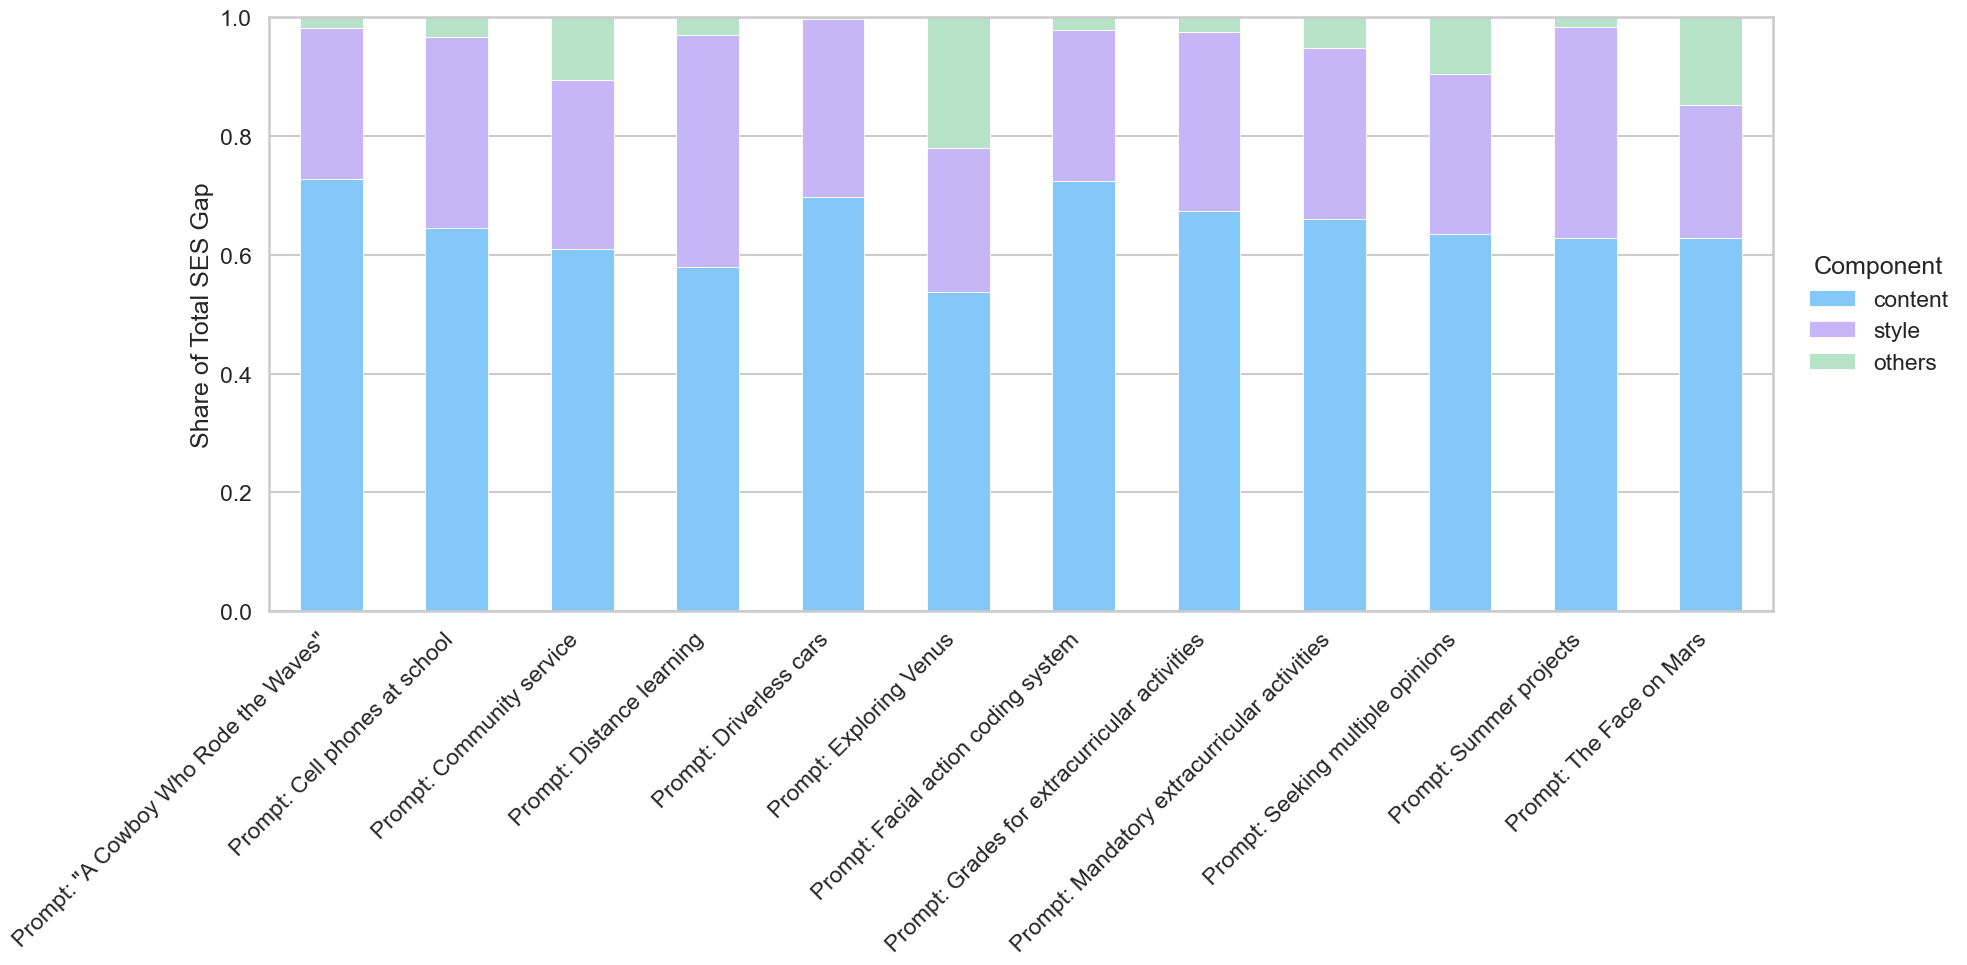

In [79]:
decomp_shares = compute_decomp_shares(df_decomp)

plot_stacked(
    decomp_shares,
    figsize=(20,10),
    xtick_rotation=45,
    save_path=f"{SAVE_DIR}decomp_shares_all.png",
    label_map=GROUP_LABELS
)

plot_overview(
    decomp_shares,
    save_path=f"{SAVE_DIR}decomp_shares_overview.png",
    label_map=GROUP_LABELS
)

plot_prompts(
    decomp_shares,
    figsize=(20,10),
    save_path=f"{SAVE_DIR}decomp_shares_prompts.png",
    label_map=GROUP_LABELS
)

In [80]:
# ---------- Core: compute shares with naive SE ----------
def _mean_and_se(s: pd.Series, mask: pd.Series):
    x = s[mask & s.notna()].astype(float)
    n = x.size
    if n == 0:
        return np.nan, np.nan, 0
    mean = float(x.mean())
    # sample std with ddof=1; if n==1, fallback to 0.0
    sd = float(x.std(ddof=1)) if n > 1 else 0.0
    se = sd / np.sqrt(n) if n > 0 else np.nan
    return mean, se, n

def _compute_decomp_with_se(df_sub):
    # restrict to k==0 as in your logic
    m_k0 = (df_sub["k"] == 0)

    # hi / lo masks for availability
    m_hi = m_k0 & (df_sub["low_SES"] == 0)
    m_lo = m_k0 & (df_sub["low_SES"] == 1)

    # require that both groups exist and have data
    if not (m_hi.any() and m_lo.any()):
        return pd.Series(
            {**{c: np.nan for c in COMP_ORDER},
             **{f"se_{c}": np.nan for c in COMP_ORDER}}
        )

    # Means and SEs for the *observables* used in each component
    # Total gap uses score_high_full (hi) vs score_low_full (lo)
    mean_hi_full, se_hi_full, _ = _mean_and_se(df_sub["score_high_full"], m_hi & df_sub["score_high_full"].notna())
    mean_lo_full, se_lo_full, _ = _mean_and_se(df_sub["score_low_full"],  m_lo & df_sub["score_low_full"].notna())
    total_gap = mean_hi_full - mean_lo_full
    var_total = se_hi_full**2 + se_lo_full**2  # naive, ignores covariance
    se_total = np.sqrt(var_total)

    # Content uses fe_essay (hi vs lo)
    mean_hi_cont, se_hi_cont, _ = _mean_and_se(df_sub["fe_essay"], m_hi & df_sub["fe_essay"].notna())
    mean_lo_cont, se_lo_cont, _ = _mean_and_se(df_sub["fe_essay"], m_lo & df_sub["fe_essay"].notna())
    content_gap = mean_hi_cont - mean_lo_cont
    var_content = se_hi_cont**2 + se_lo_cont**2
    se_content_gap = np.sqrt(var_content)

    # Style uses u (hi vs lo)
    mean_hi_style, se_hi_style, _ = _mean_and_se(df_sub["u"], m_hi & df_sub["u"].notna())
    mean_lo_style, se_lo_style, _ = _mean_and_se(df_sub["u"], m_lo & df_sub["u"].notna())
    style_gap = mean_hi_style - mean_lo_style
    var_style = se_hi_style**2 + se_lo_style**2
    se_style_gap = np.sqrt(var_style)

    # Others = total - content - style
    others_gap = total_gap - (content_gap + style_gap)
    # naive var(others) = var(total) + var(content) + var(style) (ignoring covariances and signs)
    var_others = var_total + var_content + var_style
    se_others_gap = np.sqrt(var_others)

    # Guard against divide-by-zero / nan
    if not (pd.notna(total_gap) and total_gap != 0):
        return pd.Series(
            {**{c: np.nan for c in COMP_ORDER},
             **{f"se_{c}": np.nan for c in COMP_ORDER}}
        )

    # Shares
    content_share = content_gap / total_gap
    style_share   = style_gap   / total_gap
    others_share  = others_gap  / total_gap

    # Naive delta-method SEs for shares: r = g / T, Var(r) ≈ (1/T^2)Var(g) + (g^2/T^4)Var(T)
    T = total_gap
    T2, T4 = T**2, T**4
    se_share_content = np.sqrt((var_content / T2) + (content_gap**2 * var_total / T4))
    se_share_style   = np.sqrt((var_style   / T2) + (style_gap**2   * var_total / T4))
    se_share_others  = np.sqrt((var_others  / T2) + (others_gap**2  * var_total / T4))

    return pd.Series({
        "content": content_share,
        "style":   style_share,
        "others":  others_share,
        "se_content": se_share_content,
        "se_style":   se_share_style,
        "se_others":  se_share_others
    })

def compute_decomp_shares_with_se(df_decomp):
    df = df_decomp.copy()

    groups = {"All": df}

    # by race / gender (as before)
    for g in ["race_white", "gender_male"]:
        if g in df.columns:
            groups[f"{g}=True"]  = df[df[g] == True]
            groups[f"{g}=False"] = df[df[g] == False]

    # by grade_level (NEW)
    if "grade_level" in df.columns:
        # sort unique grade values (handles float like 6.0, 8.0, ...)
        for gl in sorted(df["grade_level"].dropna().unique()):
            groups[f"grade_level={gl}"] = df[df["grade_level"] == gl]

    # by prompt_name (as before)
    if "prompt_name" in df.columns:
        for p in sorted(df["prompt_name"].dropna().unique()):
            groups[f"Prompt: {p}"] = df[df["prompt_name"] == p]

    out = pd.DataFrame({k: _compute_decomp_with_se(v) for k, v in groups.items()}).T
    cols = COMP_ORDER + [f"se_{c}" for c in COMP_ORDER]
    return out.reindex(columns=cols)


In [81]:
decomp_shares_se = compute_decomp_shares_with_se(df_decomp)

# After computing decomp_shares_se with SE columns
table_fmt = decomp_shares_se.copy()

# Round to 2 decimals
for c in COMP_ORDER + [f"se_{c}" for c in COMP_ORDER]:
    table_fmt[c] = table_fmt[c].round(2)

# Combine share ± SE into one string per component
for comp in COMP_ORDER:
    se_col = f"se_{comp}"
    table_fmt[comp] = table_fmt.apply(
        lambda r: f"{r[comp]} ± {r[se_col]}" if pd.notna(r[comp]) and pd.notna(r[se_col]) else np.nan,
        axis=1
    )

# Drop separate SE columns for cleaner output (optional)
table_fmt = table_fmt[COMP_ORDER]

# Apply label mapping for readability
table_fmt.index = table_fmt.index.map(lambda x: GROUP_LABELS.get(x, x))

# Save or display
table_fmt.to_csv(f"{SAVE_DIR}/tables/decomp_shares_tables.csv")
table_fmt.to_latex(f"{SAVE_DIR}/tables/decomp_shares_tables.tex")
display(table_fmt)


,content,style,others
All,0.72 ± 0.02,0.22 ± 0.01,0.05 ± 0.03
White,0.71 ± 0.04,0.22 ± 0.01,0.07 ± 0.05
Non-White,0.75 ± 0.03,0.21 ± 0.01,0.04 ± 0.04
Male,0.74 ± 0.03,0.22 ± 0.01,0.04 ± 0.04
Female,0.71 ± 0.03,0.23 ± 0.01,0.06 ± 0.04
Grade 6,0.73 ± 0.16,0.25 ± 0.06,0.02 ± 0.19
Grade 8,0.71 ± 0.03,0.23 ± 0.01,0.06 ± 0.04
Grade 10,0.65 ± 0.05,0.27 ± 0.02,0.08 ± 0.06
Grade 11,0.57 ± 0.06,0.36 ± 0.04,0.07 ± 0.09
"Prompt: ""A Cowboy Who Rode the Waves""",0.73 ± 0.16,0.25 ± 0.06,0.02 ± 0.19
